In [1]:
import sys
from pathlib import Path

repo_parent = str(Path("/Users/yaniszaim").resolve())
if repo_parent not in sys.path:
    sys.path.insert(0, repo_parent)

print(sys.path[0])

/Users/yaniszaim


In [2]:
import deephedging
print(deephedging.__file__)

/Users/yaniszaim/deephedging/__init__.py


In [3]:
import sys
print(sys.executable)

/opt/anaconda3/envs/dh/bin/python


# BLACK SCHOLES WORLD

## Vanilla DH BS - No initial Delta, No Recurrence

In [13]:
print("Deep Hedging AI says hello ... ", end='')
from cdxbasics.config import Config
from deephedging.trainer import train
from deephedging.gym import VanillaDeepHedgingGym
from deephedging.world import SimpleWorld_Spot_ATM

from IPython.display import display, Markdown

# see print of the config below for numerous options
config = Config()
# world
config.world.samples = 10000
config.world.steps = 20
config.world.black_scholes = True
# gym
config.gym.objective.utility = "cvar"
config.gym.objective.lmbda = 1.
config.gym.agent.network.depth = 3
config.gym.agent.network.activation = "softplus"
# trainer
config.trainer.train.optimizer.name = "adam"
#config.trainer.train.optimizer.learning_rate = 0.001
#config.trainer.train.optimizer.clipvalue = 1.
#config.trainer.train.optimizer.global_clipnorm = 1.
config.trainer.train.batch_size = None
config.trainer.train.epochs = 800
config.trainer.caching.mode = "on"
config.trainer.visual.epoch_refresh = 5
config.trainer.visual.confidence_pcnt_lo = 0.25
config.trainer.visual.confidence_pcnt_hi = 0.75

# Disable initial delta
config.gym.agent.init_delta.active = False

display(Markdown("## Deep Hedging in a Black \& Scholes World"))

# create world
world  = SimpleWorld_Spot_ATM( config.world )
val_world  = world.clone(samples=world.nSamples//10)

# create training environment
gym_vanilla = VanillaDeepHedgingGym( config.gym )

# create training environment
train( gym=gym_vanilla, world=world, val_world=val_world, config=config.trainer )
r = gym_vanilla(world.tf_data)
print("Keys of the dictionary returned by the gym: ", r.keys())

print("=========================================")
print("Config usage report")
print("=========================================")
print( config.usage_report() )
config.done()

Deep Hedging AI says hello ... 

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

## Prototype-Based Black Scholes

Initializing training at 2025-06-19 16:03:42: gym with 102 trainable weights compiled. Took 0s
ProtoAgent using 100 trainable weights for 1 instruments.
Features used: delta, price and time_left
Monetary utility cvar@1 is using 1 weight
 Features available: cost, ivol, lbnd_a, price, spot, sqrt_time_left, time_left and ubnd_a
 Features used:      -
Caching enabled @ '/Users/lisafaloughi/Desktop/DeepHedging/deephedging/notebooks/.deephedging_cache/proto_bs_100/792e1dc1f1b876b871b07a0dde8be9481567e23b7f0f02de.pck'
Cache successfully loaded. Current epoch: 800
Nothing to do: cached model loaded from /Users/lisafaloughi/Desktop/DeepHedging/deephedging/notebooks/.deephedging_cache/proto_bs_100/792e1dc1f1b876b871b07a0dde8be9481567e23b7f0f02de.pck was trained for 800 epochs; you have asked to train for 800 epochs. If you want to force training: raise number of epochs or turn off caching.
Plotting results for the trained model.
Training monitor initialized. Took 0s
                            

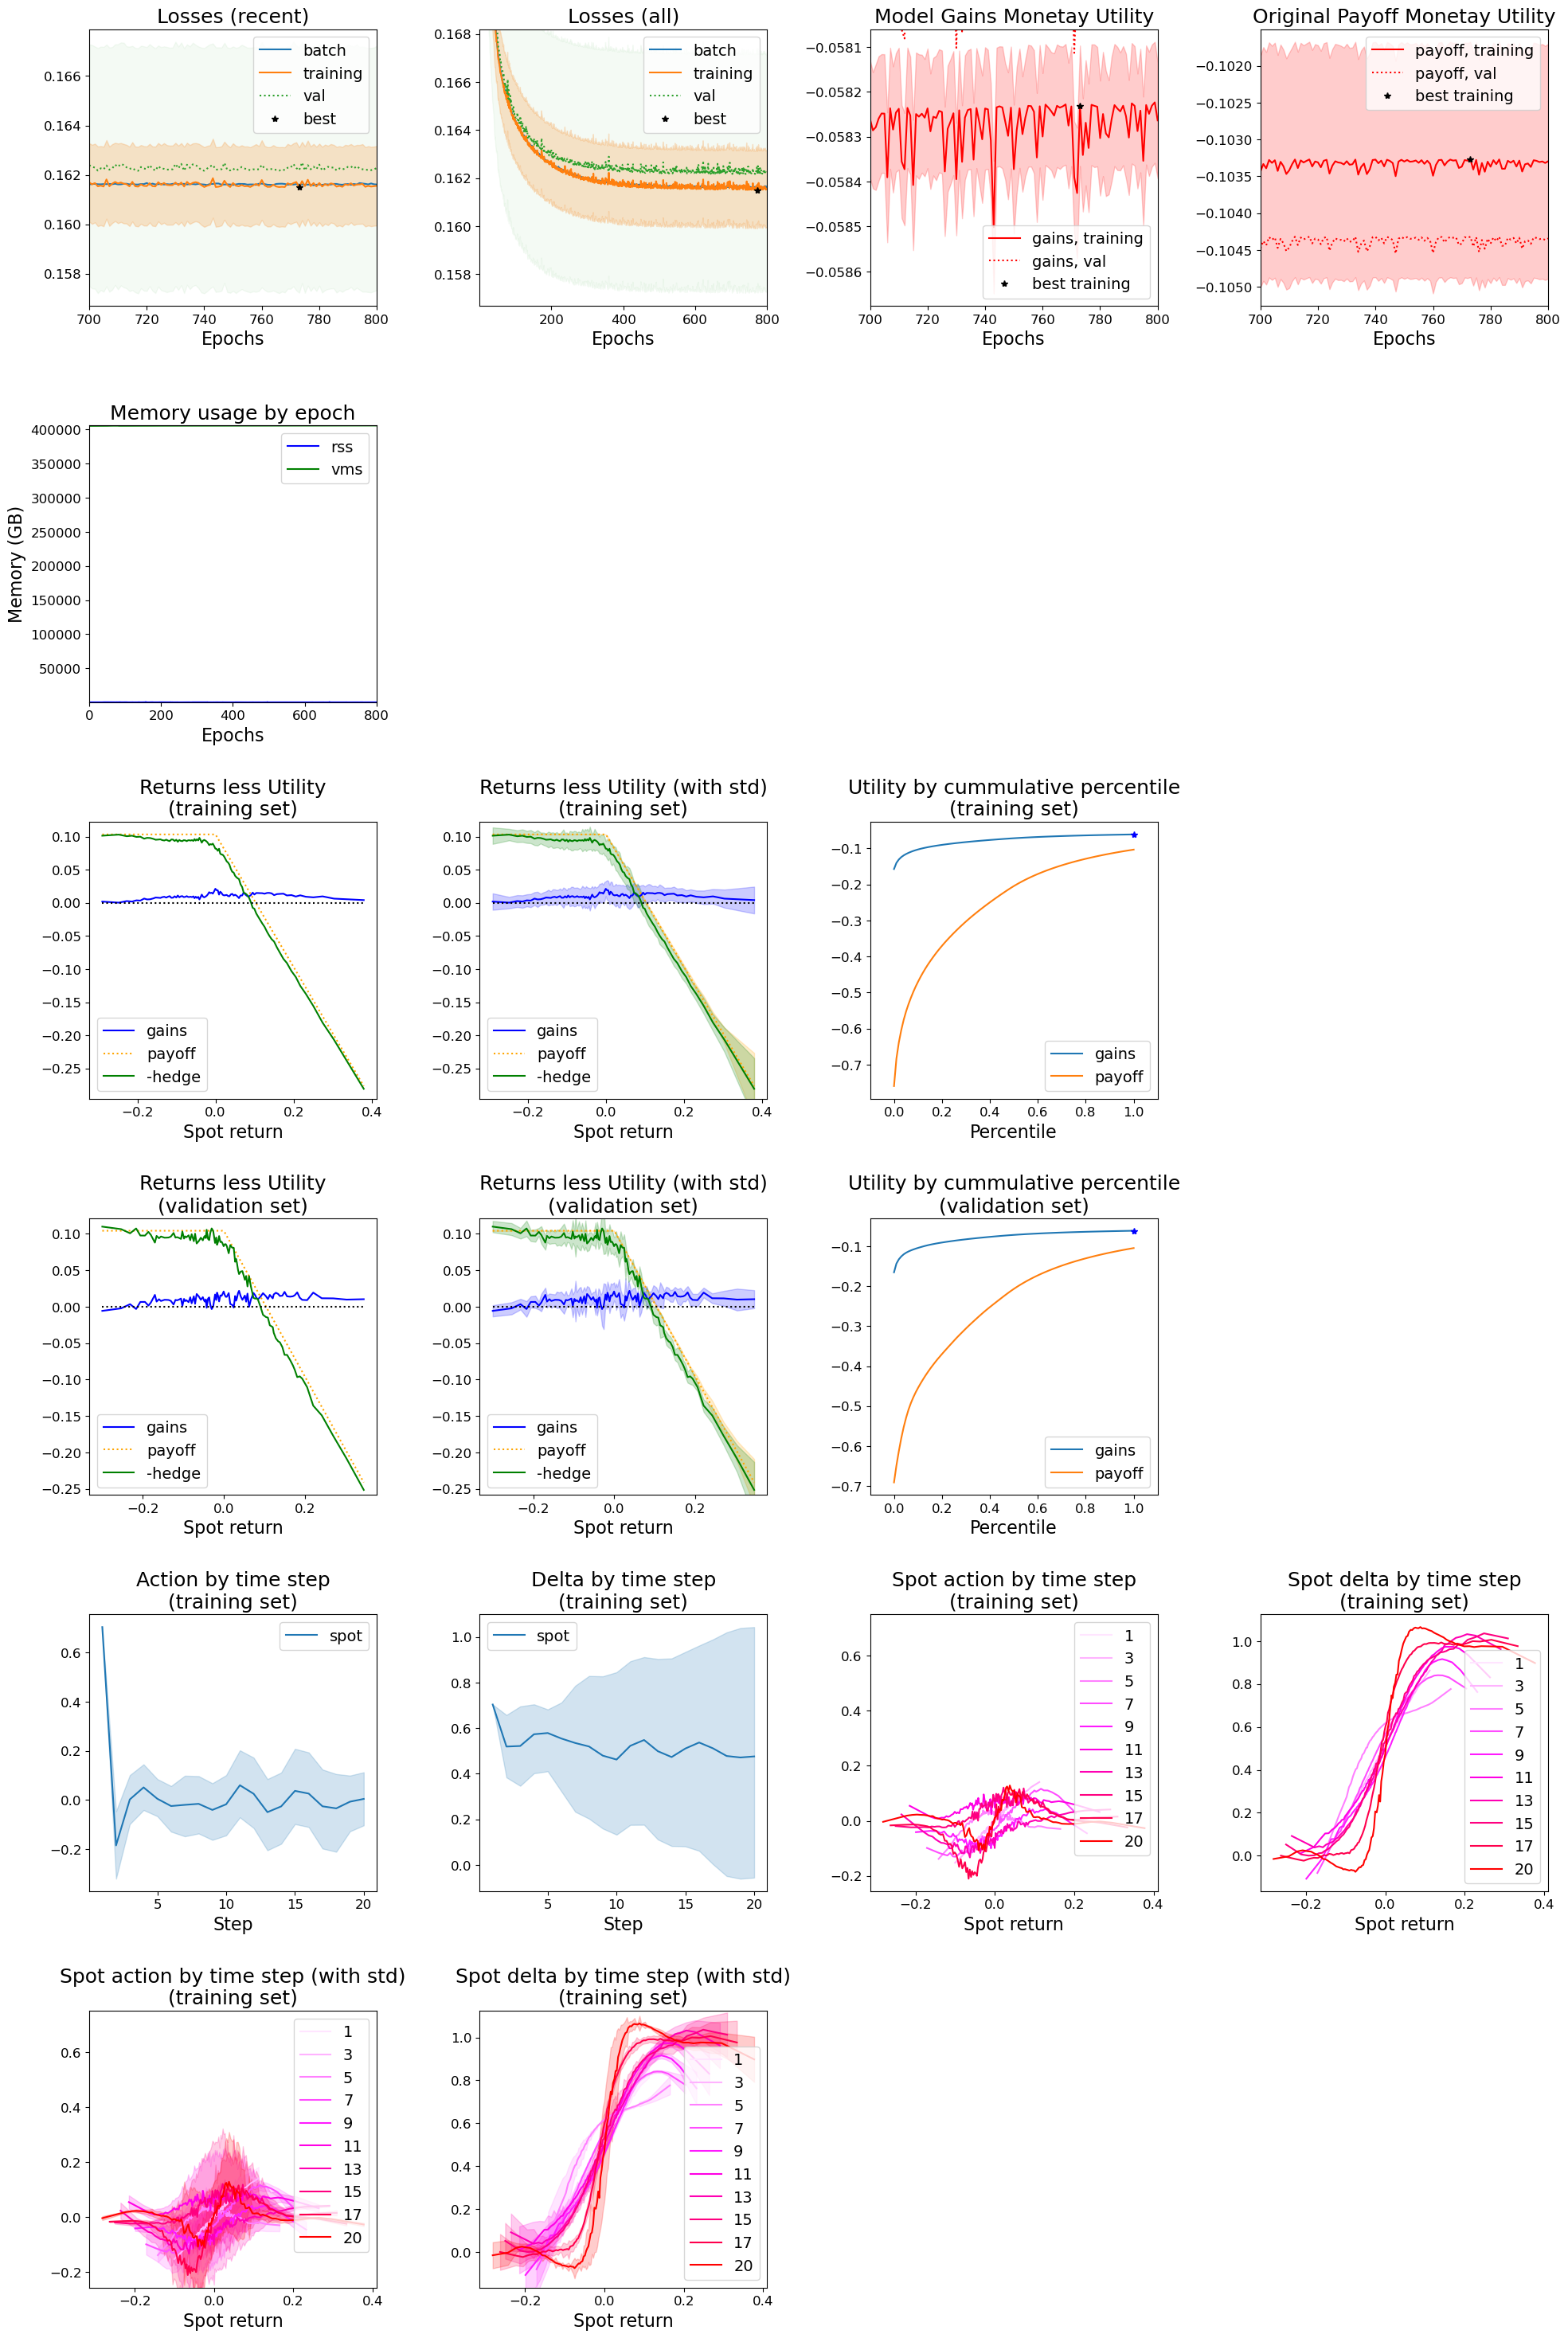

Training 800/800 epochs; 102 weights; 10000 samples; 1000 validation samples batch size 32 | initial loss 0.666611 (0.01019), training 0.161559 (0.00160524), best 0.161502 (0.01019), batch 0.161611, val 0.162283 (0.00494301); best epoch 773, last cached 800 | memory used: rss 177.062M, vms 405771M | time elapsed 45:54; time per epoch 3s; estimated time remaining 0s | current time: 2025-06-19 16:03:45                        
 Status: Cached model already sufficiently trained.
 Weights set to best epoch: 773
 State of training until epoch 800 cached into /Users/lisafaloughi/Desktop/DeepHedging/deephedging/notebooks/.deephedging_cache/proto_bs_100/792e1dc1f1b876b871b07a0dde8be9481567e23b7f0f02de.pck
 Time: 2025-06-19 16:03:46
Training terminated. Total time taken 3s
Keys of the dictionary returned by the gym:  odict_keys(['loss', 'utility', 'utility0', 'gains', 'payoff', 'pnl', 'cost', 'actions'])
Config usage report
config.gym.agent.environment['hard_clip'] = False # Use min/max instread

In [55]:
# In your notebook or training script:
import pickle
from deephedging.gym import VanillaDeepHedgingGym
from deephedging.trainer import train
from deephedging.world import SimpleWorld_Spot_ATM
from cdxbasics.config import Config

# 1. Load configuration
config = Config()
n_prototypes = 100

# 2. World setup
config.world.samples = 10000
config.world.steps = 20
config.world.black_scholes = True

# 3. Gym setup with ProtoAgent
config.gym.agent.agent_type = "protopnet"  # Tells AgentFactory to use ProtoAgent
config.gym.agent.features = ["price", "delta", "time_left"]  # Must match prototype dimensions
config.gym.agent.prototype_path = f"./prototypes_storage/prototypes_{n_prototypes}.pkl"

config.gym.objective.utility = "cvar"
config.gym.objective.lmbda = 1.

# 4. Load saved prototypes (used inside ProtoPNetLayer)
with open(f"./prototypes_storage/prototypes_{n_prototypes}.pkl", "rb") as f:
    prototypes = pickle.load(f)

# 5. Trainer config
config.trainer.train.epochs = 800
config.trainer.caching.directory = f"./.deephedging_cache/proto_bs_{n_prototypes}"

config.trainer.caching.mode = "on"  # Important to avoid reusing old cache
config.trainer.visual.epoch_refresh = 5

config.trainer.train.optimizer.name = "adam"

config.trainer.train.batch_size = None
config.trainer.visual.confidence_pcnt_lo = 0.25
config.trainer.visual.confidence_pcnt_hi = 0.75

# 6. Build world & val_world
world = SimpleWorld_Spot_ATM(config.world)
val_world = world.clone(samples=world.nSamples // 10)

# 7. Create the gym (automatically uses ProtoAgent via AgentFactory)
gym = VanillaDeepHedgingGym(config.gym)

# 8. Train the model using the prototype-based agent
train(gym=gym, world=world, val_world=val_world, config=config.trainer)

r = gym(world.tf_data)
print("Keys of the dictionary returned by the gym: ", r.keys())

print("=========================================")
print("Config usage report")
print("=========================================")
print( config.usage_report() )
config.done()

## NEW WEIGHTED SIMILARITY

Initializing training at 2025-07-24 13:56:05: gym with 105 trainable weights compiled. Took 0s
ProtoAgent using 103 trainable weights for 1 instruments.
Features used: delta, price and time_left
Monetary utility cvar@1 is using 1 weight
 Features available: cost, ivol, lbnd_a, price, spot, sqrt_time_left, time_left and ubnd_a
 Features used:      -
Caching enabled @ '/Users/lisafaloughi/Desktop/DeepHedging/deephedging/notebooks/.deephedging_cache/proto_bs_100_weights_trained_v1/792e1dc1f1b876b871b07a0dde8be9481567e23b7f0f02de.pck'
Training monitor initialized. Took 0s
                                                                                                                                                                                                         


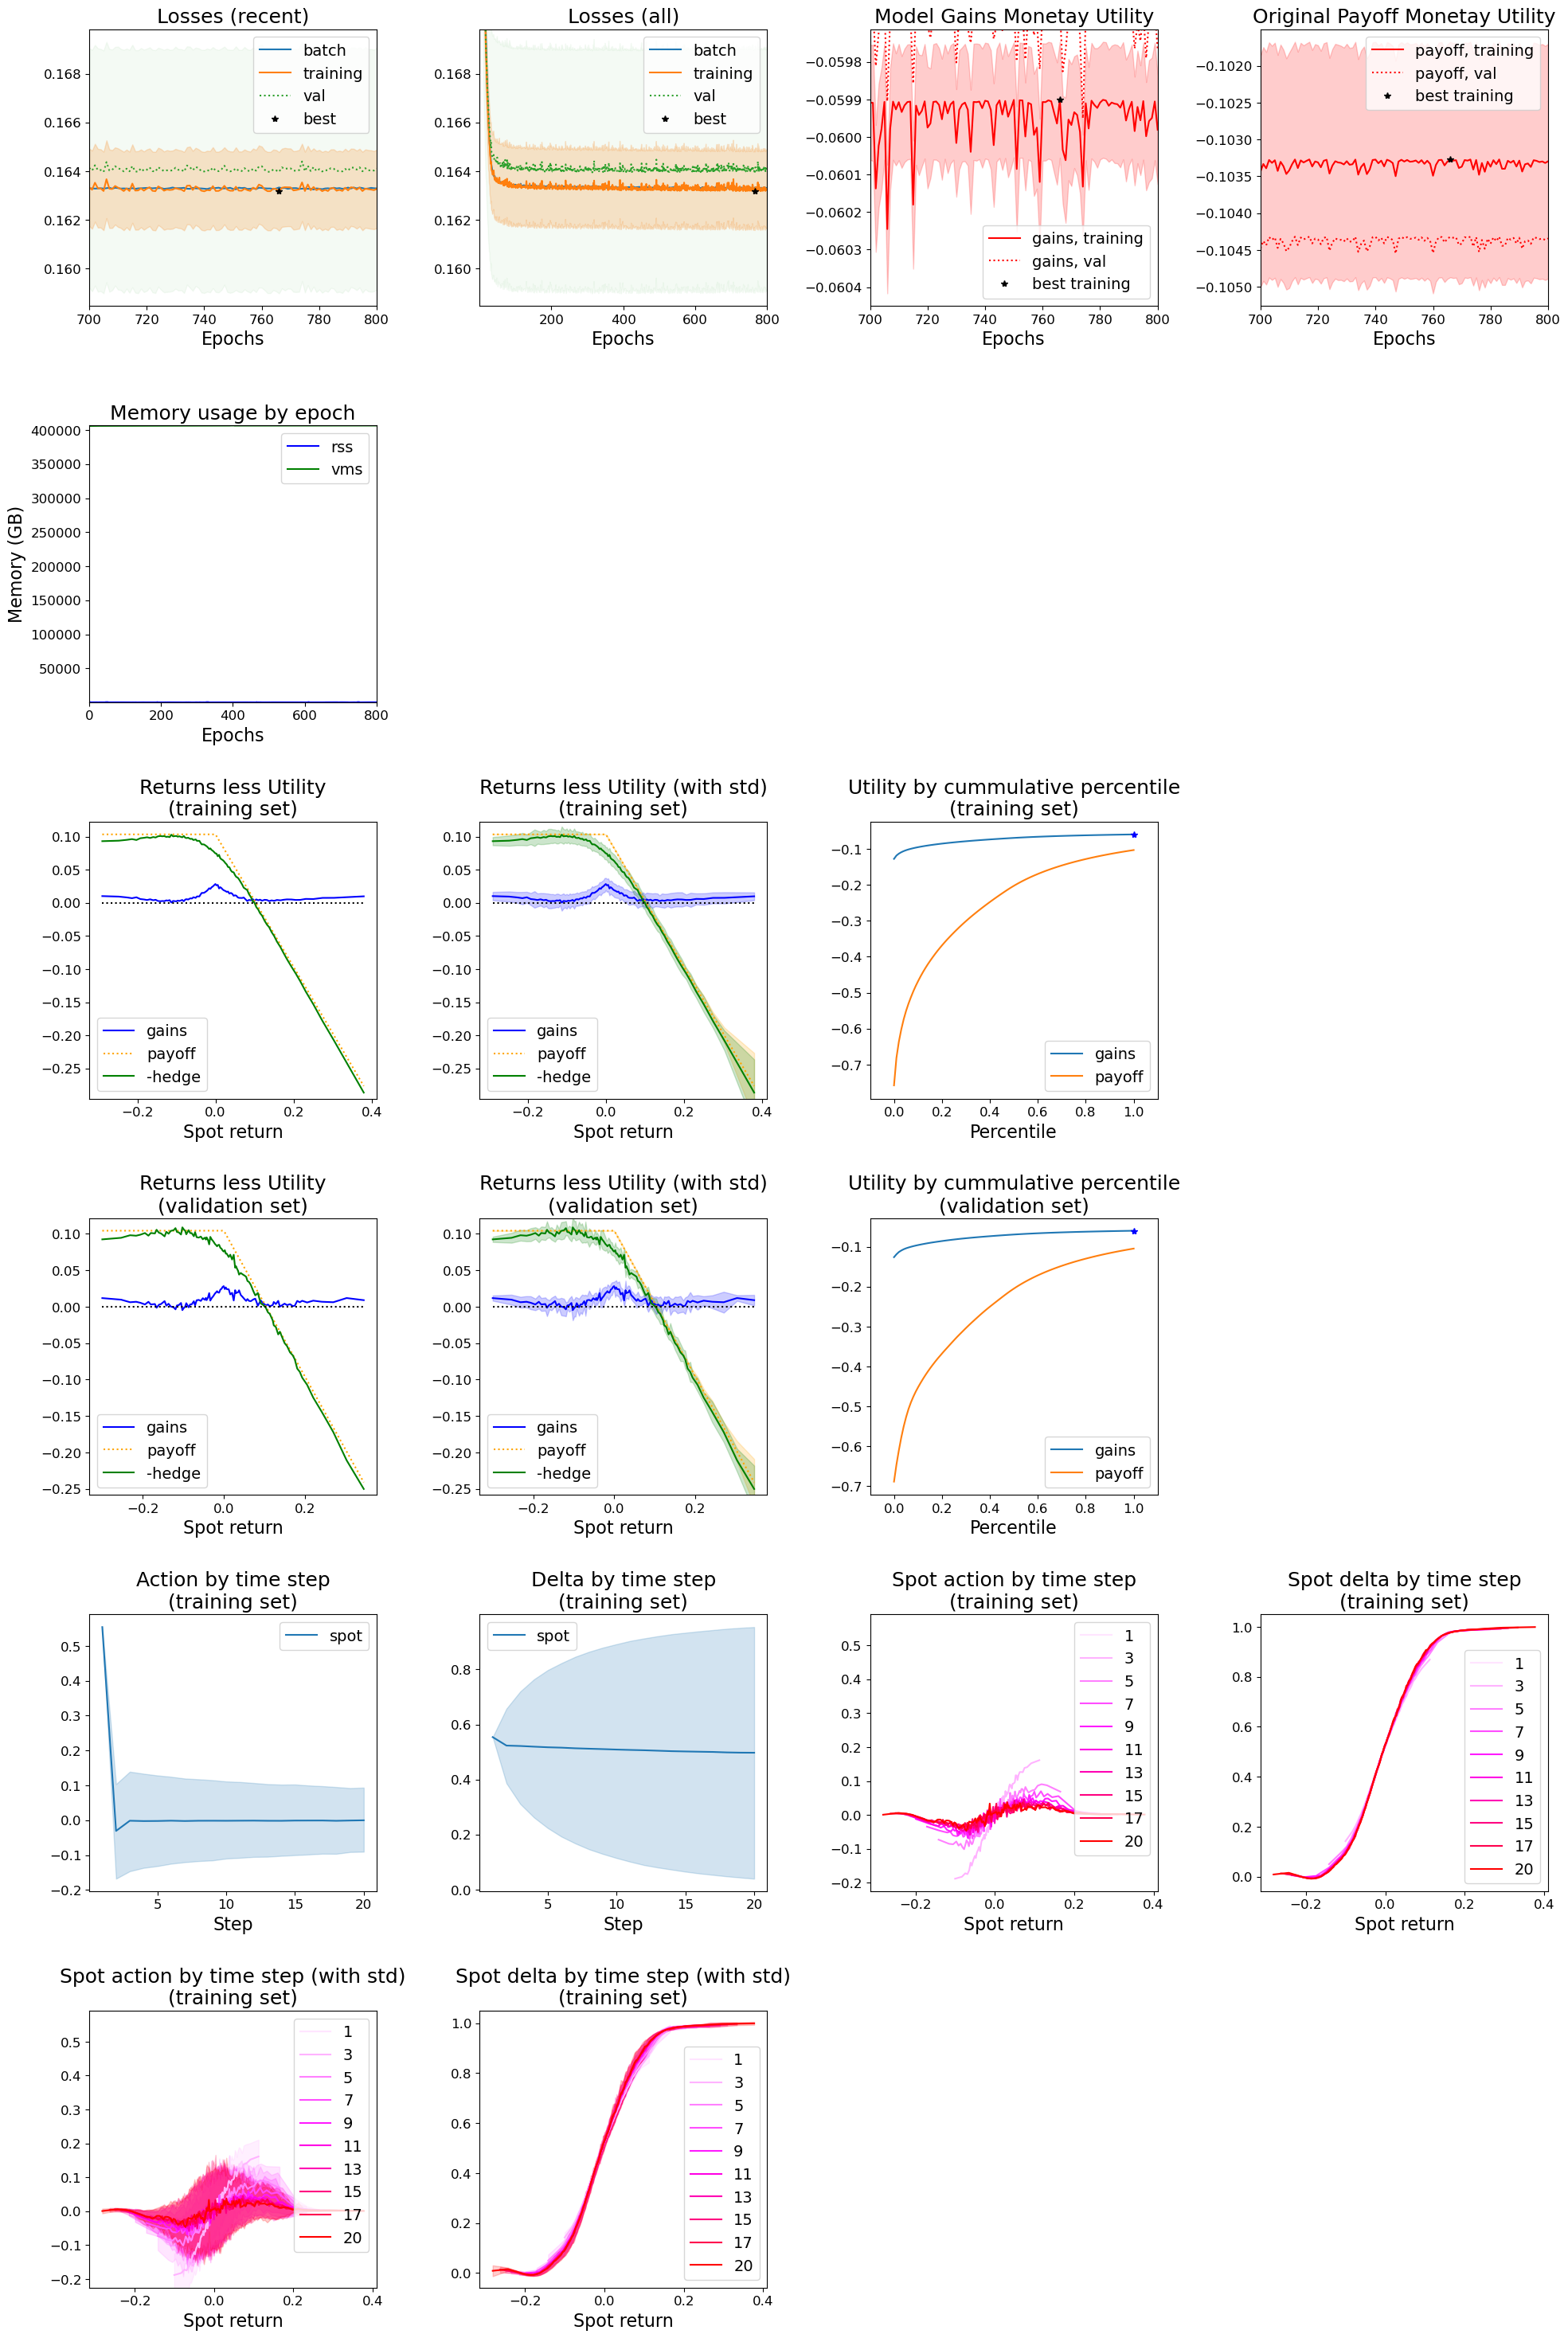

Training 800/800 epochs; 105 weights; 10000 samples; 1000 validation samples batch size 32 | initial loss 0.660762 (0.0100997), training 0.163276 (0.00160517), best 0.163174 (0.0100997), batch 0.163292, val 0.164107 (0.00496668); best epoch 766, last cached 800 | memory used: rss 247.984M, vms 406616M | time elapsed 44:08; time per epoch 3s; estimated time remaining 0s | current time: 2025-07-24 14:40:16                        25-07-24 14:40:14                           
 Status: Training complete.
 Weights set to best epoch: 766
 State of training until epoch 800 cached into /Users/lisafaloughi/Desktop/DeepHedging/deephedging/notebooks/.deephedging_cache/proto_bs_100_weights_trained_v1/792e1dc1f1b876b871b07a0dde8be9481567e23b7f0f02de.pck
 Time: 2025-07-24 14:40:17
Training terminated. Total time taken 44:11
Keys of the dictionary returned by the gym:  odict_keys(['loss', 'utility', 'utility0', 'gains', 'payoff', 'pnl', 'cost', 'actions'])
Config usage report
config.gym.agent.environme

In [48]:
# In your notebook or training script:
import pickle
from deephedging.gym import VanillaDeepHedgingGym
from deephedging.trainer import train
from deephedging.world import SimpleWorld_Spot_ATM
from cdxbasics.config import Config

# 1. Load configuration
config = Config()
n_prototypes = 100

# 2. World setup
config.world.samples = 10000
config.world.steps = 20
config.world.black_scholes = True

# 3. Gym setup with ProtoAgent
config.gym.agent.agent_type = "protopnet"  # Tells AgentFactory to use ProtoAgent
config.gym.agent.features = ["price", "delta", "time_left"]  # Must match prototype dimensions
config.gym.agent.prototype_path = f"./prototypes_storage/prototypes_{n_prototypes}.pkl"

config.gym.objective.utility = "cvar"
config.gym.objective.lmbda = 1.

# 4. Load saved prototypes (used inside ProtoPNetLayer)
with open(f"./prototypes_storage/prototypes_{n_prototypes}.pkl", "rb") as f:
    prototypes = pickle.load(f)

# 5. Trainer config
config.trainer.train.epochs = 800
config.trainer.caching.directory = f"./.deephedging_cache/proto_bs_{n_prototypes}_weights_trained_v1"

config.trainer.caching.mode = "on"  # Important to avoid reusing old cache
config.trainer.visual.epoch_refresh = 5

config.trainer.train.optimizer.name = "adam"

config.trainer.train.batch_size = None
config.trainer.visual.confidence_pcnt_lo = 0.25
config.trainer.visual.confidence_pcnt_hi = 0.75

# 6. Build world & val_world
world = SimpleWorld_Spot_ATM(config.world)
val_world = world.clone(samples=world.nSamples // 10)

# 7. Create the gym (automatically uses ProtoAgent via AgentFactory)
gym = VanillaDeepHedgingGym(config.gym)

# 8. Train the model using the prototype-based agent
train(gym=gym, world=world, val_world=val_world, config=config.trainer)

r = gym(world.tf_data)
print("Keys of the dictionary returned by the gym: ", r.keys())

print("=========================================")
print("Config usage report")
print("=========================================")
print( config.usage_report() )
config.done()

## Black Scholes Analysis 

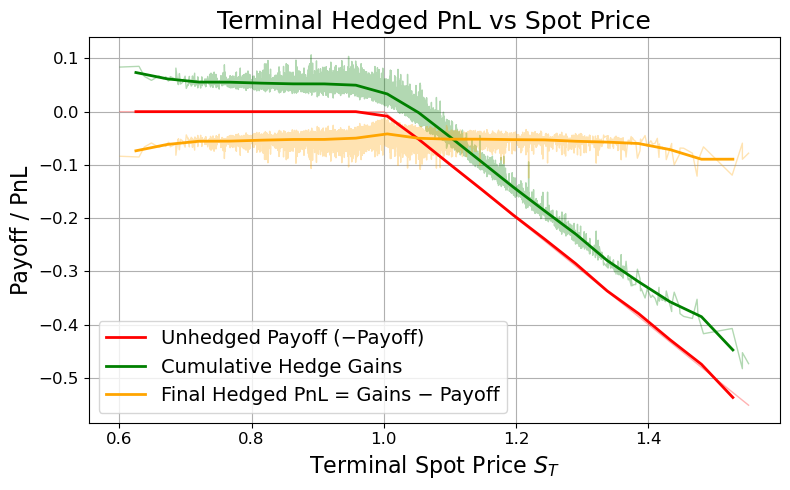

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from deephedging.base import npCast

# Step 1: Extract data
spotT = world.details.spot_all[:, -1]
payoff = npCast(r["payoff"])
dh_pnl = -npCast(r["pnl"])
terminal_pnl = payoff - dh_pnl

# Step 2: Define bins and compute bin centers
n_bins = 20
bins = np.linspace(spotT.min(), spotT.max(), n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Step 3: Initialize arrays
payoff_binned = np.zeros(n_bins)
gain_binned = np.zeros(n_bins)
total_binned = np.zeros(n_bins)

# Step 4: Bin data
for i in range(n_bins):
    mask = (spotT >= bins[i]) & (spotT < bins[i+1])
    if np.any(mask):
        payoff_binned[i] = np.mean(payoff[mask])
        gain_binned[i] = np.mean(dh_pnl[mask])
        total_binned[i] = np.mean(terminal_pnl[mask])
    else:
        payoff_binned[i] = np.nan
        gain_binned[i] = np.nan
        total_binned[i] = np.nan

# Step 5: Sort raw data by spotT for raw (transparent) curves
ixs = np.argsort(spotT)
sorted_spotT = spotT[ixs]
sorted_payoff = payoff[ixs]
sorted_gain = dh_pnl[ixs]
sorted_total = terminal_pnl[ixs]

# Step 6: Plot both raw and binned versions
plt.figure(figsize=(8, 5))

# Plot raw data (faint, no legend)
plt.plot(sorted_spotT, sorted_payoff, label="_nolegend_", color="red", alpha=0.3, linewidth=1)
plt.plot(sorted_spotT, sorted_gain, label="_nolegend_", color="green", alpha=0.3, linewidth=1)
plt.plot(sorted_spotT, sorted_total, label="_nolegend_", color="orange", alpha=0.3, linewidth=1)

# Plot binned (smoothed) curves with legend
plt.plot(bin_centers, payoff_binned, label="Unhedged Payoff (−Payoff)", color="red", linewidth=2)
plt.plot(bin_centers, gain_binned, label="Cumulative Hedge Gains", color="green", linewidth=2)
plt.plot(bin_centers, total_binned, label="Final Hedged PnL = Gains − Payoff", color="orange", linewidth=2)

# Labels and formatting
plt.xlabel("Terminal Spot Price $S_T$")
plt.ylabel("Payoff / PnL")
plt.title("Terminal Hedged PnL vs Spot Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Running strategies ...done
Running tensorflow to compute utility of BS strategy ...done; result -0.0516349
Rendering now. Stand by.


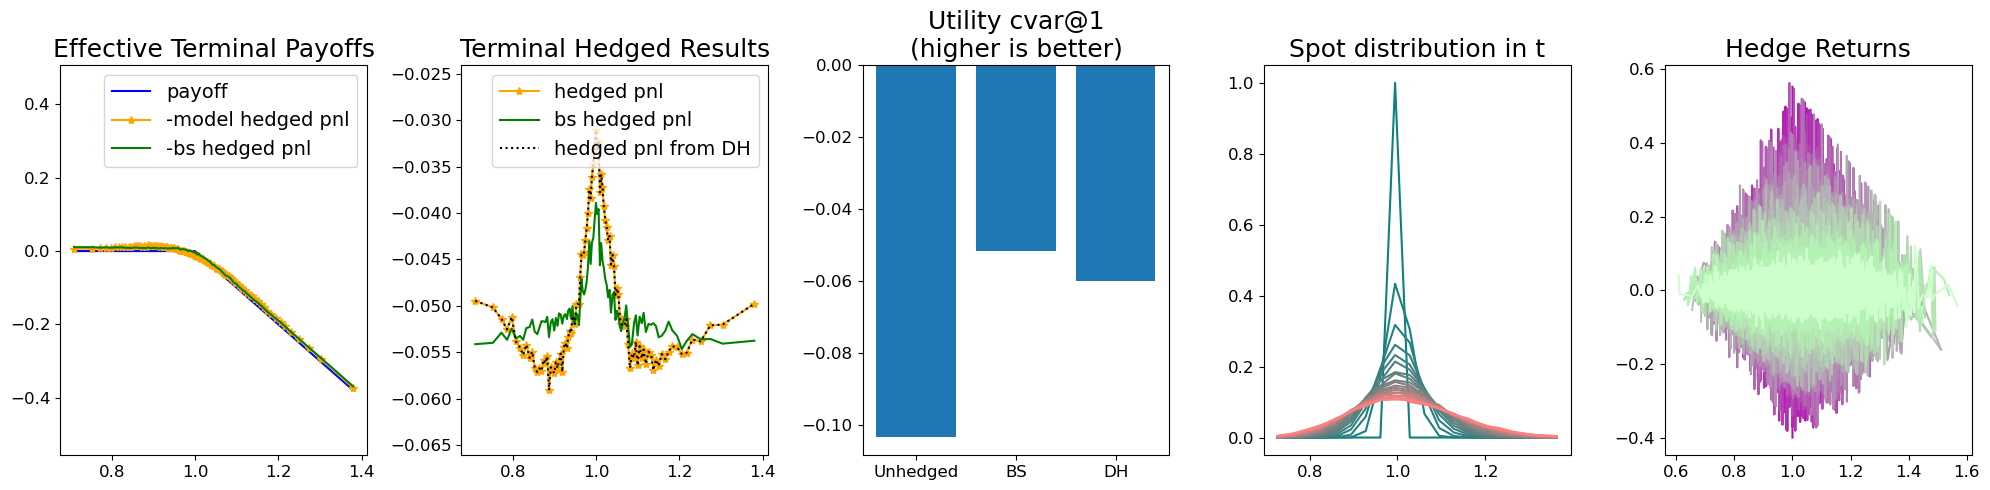

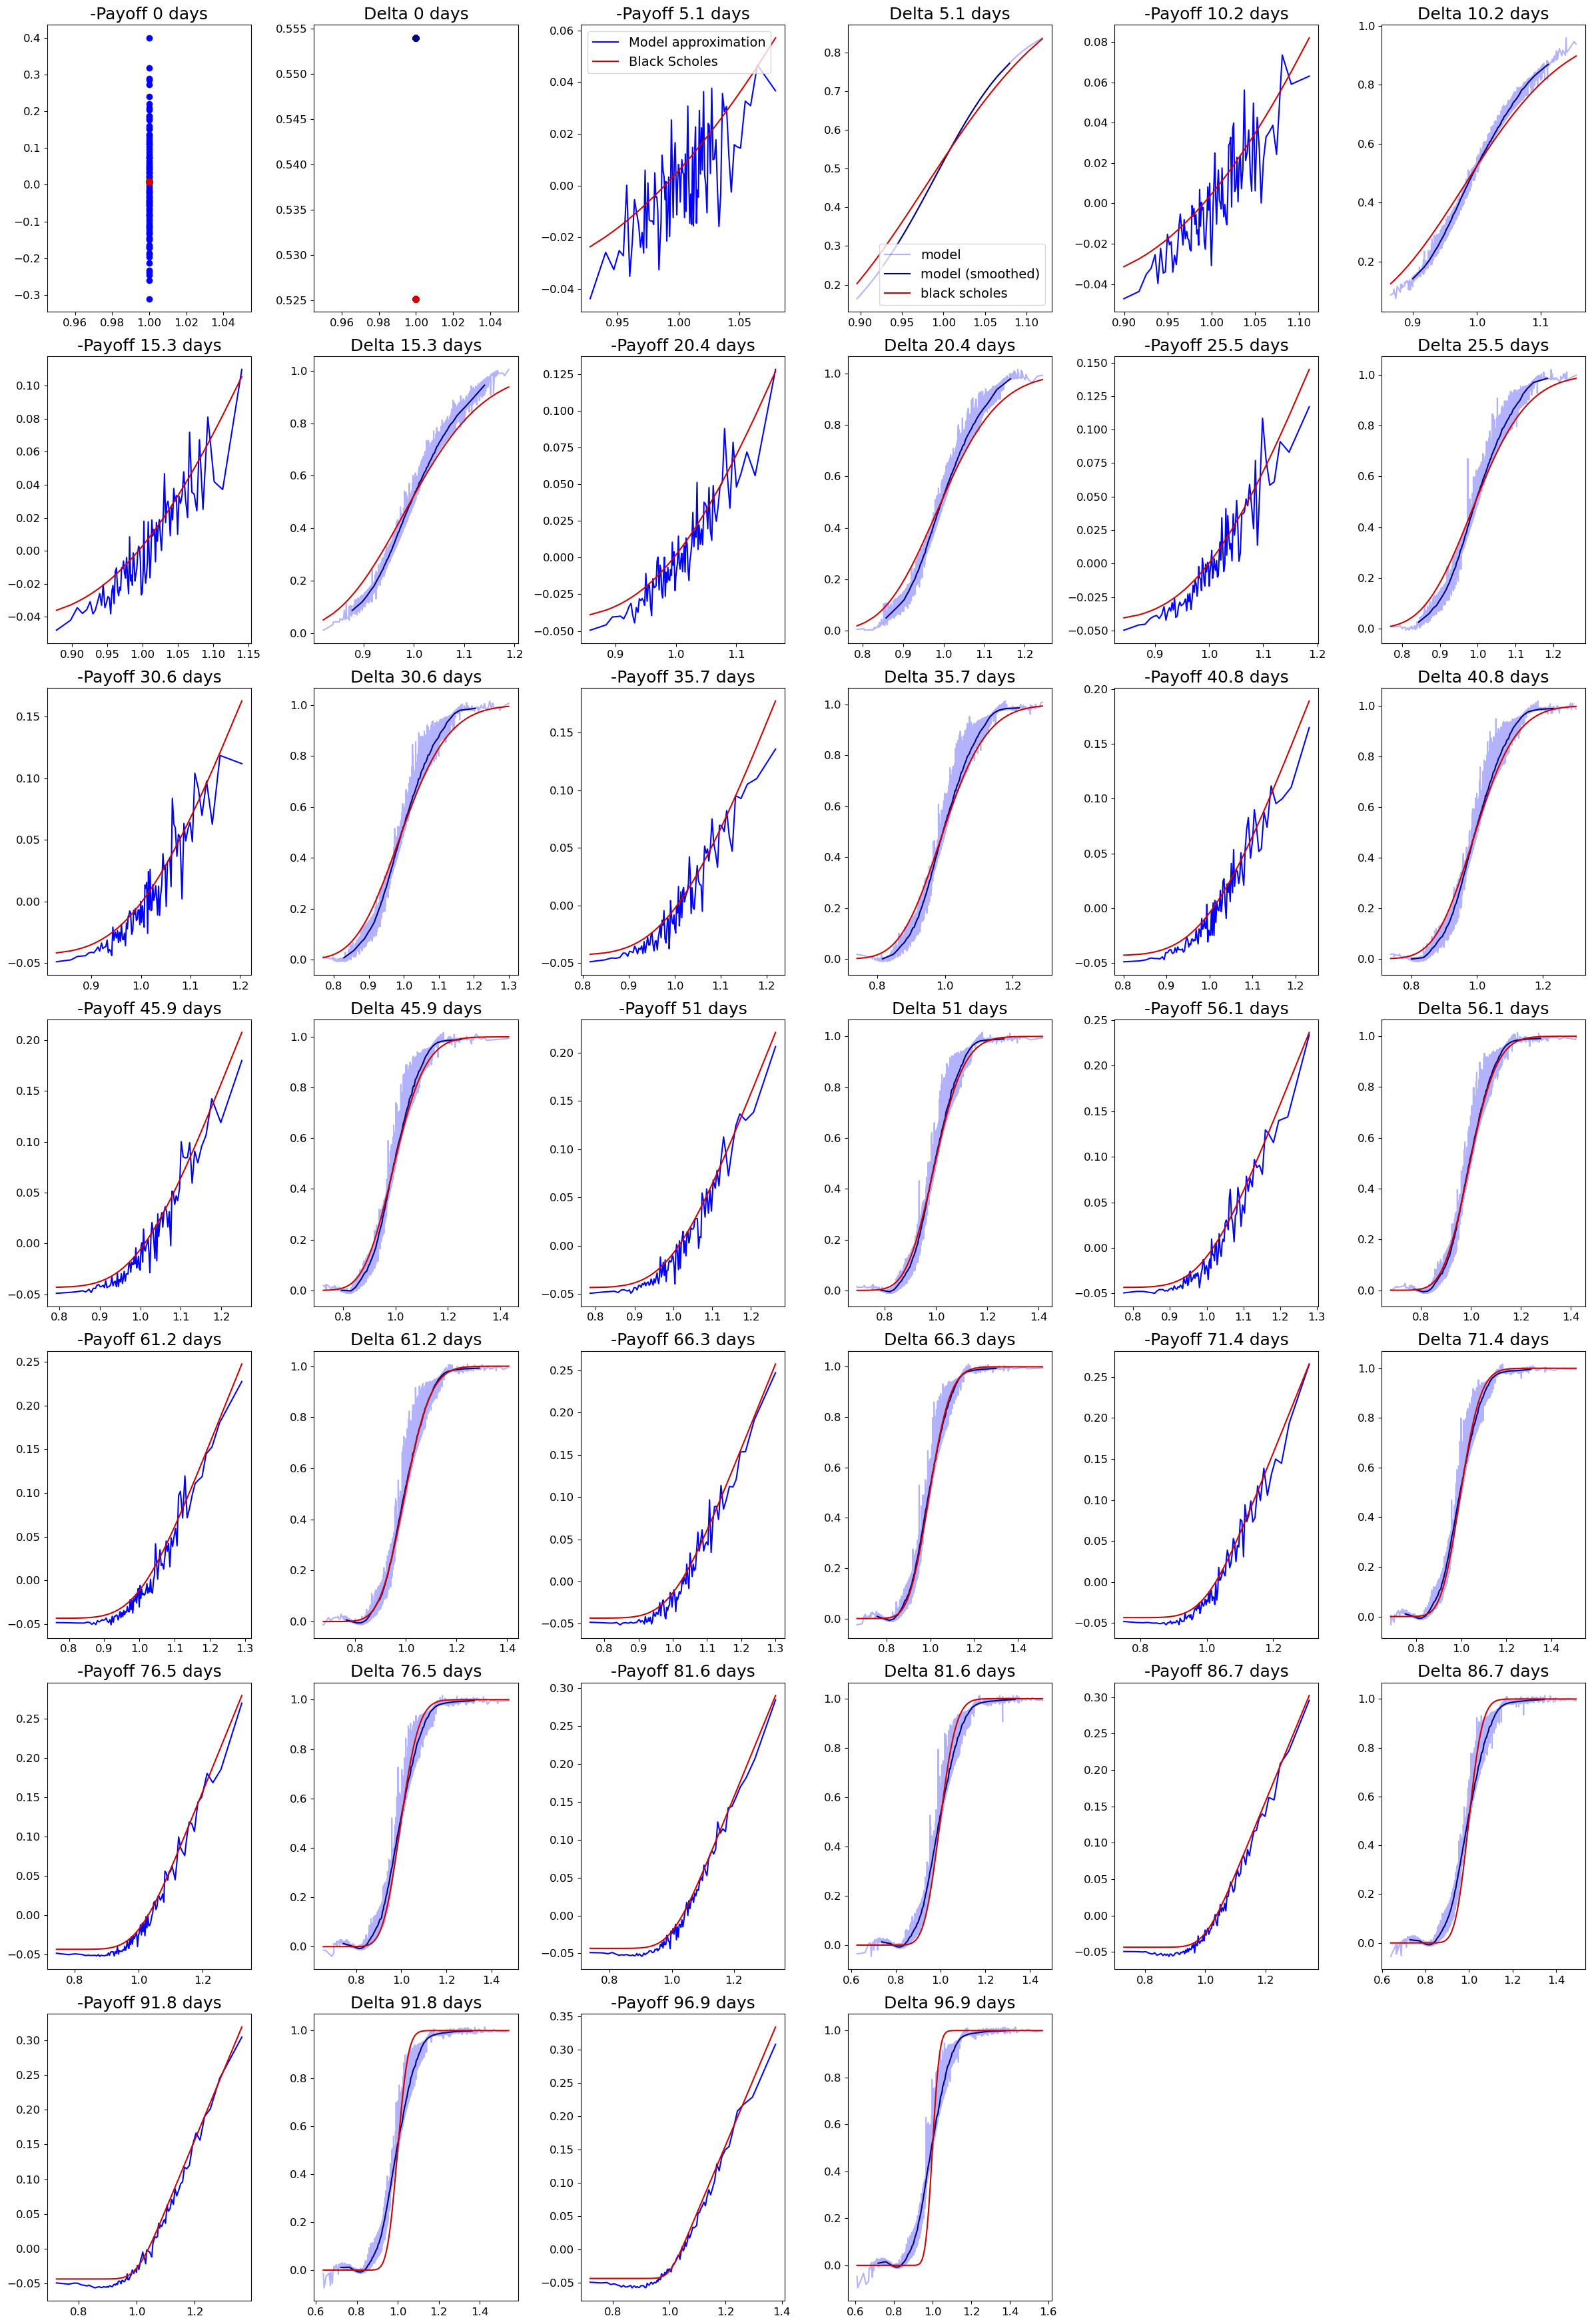

In [49]:
import deephedging.plot_bs_hedge as plot_bs_hedge
plot_bs_hedge.plot_blackscholes( world, gym, config )

## Black Scholes Inference

In [ ]:
# import tensorflow as tf
# import numpy as np

# # 1. Generate 5000 new test samples from same world
# test_world = world.clone(samples=5000)
# test_result = gym(test_world.tf_data)
# test_result_vanilla = gym_vanilla(test_world.tf_data)

In [50]:
import tensorflow as tf
import numpy as np
import random

# 1. Set global seeds for safety (optional but good practice)
seed = 1
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# 2. Use fixed seed in world clone
test_world = world.clone(seed=seed, samples=5000)

# 3. Run evaluation
test_result = gym(test_world.tf_data)
test_result_vanilla = gym_vanilla(test_world.tf_data)

FIRST VERIFY IF THE PATH WAS PROFITABLE BEFOFE PRINTING THE PATH

In [51]:
path_num = -1500
test_result["utility0"][path_num], test_result["utility"][path_num]

(<tf.Tensor: shape=(), dtype=float32, numpy=-0.13103077>,
 <tf.Tensor: shape=(), dtype=float32, numpy=-0.049995445>)

In [52]:
# 2. Extract model input features
price      = test_world.data.features.per_step['price'][path_num]       # shape (20,)
time_left  = test_world.data.features.per_step['time_left'][path_num]   # shape (20,)
actions    = test_result['actions'][path_num].numpy().flatten()         # shape (20,)

# 3. Reconstruct delta from cumulative actions
delta = np.concatenate([[0], np.cumsum(actions[:-1])])  # shape (20,)

# 4. Stack into feature vectors (must be in [delta, price, time_left] order)
X = np.stack([delta, price, time_left], axis=1)  # shape (20, 3)

# 5. Apply scaler (the one saved with prototypes)
from pickle import load
with open(f"./prototypes_storage/prototypes_{n_prototypes}.pkl", "rb") as f:
    data = load(f)
scaler = data["scaler"]
X_scaled = scaler.transform(X)

# 6. Get model components
proto_layer = gym.agent.proto_layer
prototypes = proto_layer.prototypes.numpy()
proto_actions = proto_layer.prototype_actions.numpy()

# 7. Apply same weighting as in ClusteredProtoLayer
D = prototypes.shape[1]
weights = np.ones(D, dtype=np.float32)
weights[-1] = 5  # match time_left weight
feature_weights = tf.constant(weights)


# 8. Compute distances and similarities with weighting
x_tf = tf.convert_to_tensor(X_scaled, dtype=tf.float32)
x_exp = tf.expand_dims(x_tf, axis=1)                         # [20, 1, 3]
p_exp = tf.expand_dims(proto_layer.prototypes, axis=0)       # [1, 500, 3]

# distances = tf.reduce_sum((x_exp - p_exp) ** 2, axis=2)      # [20, 500]

diff = x_exp - p_exp                                               # [T, P, D]
weighted_diff = diff * feature_weights                             # [T, P, D]
distances = tf.reduce_sum(tf.square(weighted_diff), axis=2)       # [T, P]
similarities = tf.nn.softmax(-distances, axis=1)                   # [T, P]
closest = tf.argmax(similarities, axis=1).numpy()                  # [T]

# 9. Display step-by-step explanation
for t in range(X.shape[0]):
    top3_idx = np.argsort(-similarities[t].numpy())[:3]
    print(f"\nStep {t}:")
    print(f"  Input:        delta={delta[t]:.3f}, price={price[t]:.3f}, time_left={time_left[t]:.3f}")
    print(f"  Action:       {actions[t]:.4f}")
    print(f"  Top 3 Prototypes:")
    for idx in top3_idx:
        raw_features = scaler.inverse_transform([prototypes[idx]])[0]
        print(f"    • Prototype {idx} | Features={raw_features.round(3)} | Action={proto_actions[idx].round(3)} | Similarity={similarities[t, idx].numpy():.3f}")


Step 0:
  Input:        delta=0.000, price=1.000, time_left=0.400
  Action:       0.5540
  Top 3 Prototypes:
    • Prototype 4 | Features=[-0.   1.   0.4] | Action=[0.779] | Similarity=0.957
    • Prototype 32 | Features=[0.557 0.993 0.38 ] | Action=[-0.182] | Similarity=0.014
    • Prototype 68 | Features=[0.557 1.021 0.38 ] | Action=[0.005] | Similarity=0.013

Step 1:
  Input:        delta=0.554, price=1.002, time_left=0.380
  Action:       -0.0281
  Top 3 Prototypes:
    • Prototype 32 | Features=[0.557 0.993 0.38 ] | Action=[-0.182] | Similarity=0.269
    • Prototype 68 | Features=[0.557 1.021 0.38 ] | Action=[0.005] | Similarity=0.258
    • Prototype 64 | Features=[0.557 0.962 0.38 ] | Action=[-0.805] | Similarity=0.221

Step 2:
  Input:        delta=0.526, price=1.031, time_left=0.360
  Action:       0.1138
  Top 3 Prototypes:
    • Prototype 74 | Features=[0.562 1.052 0.36 ] | Action=[0.324] | Similarity=0.213
    • Prototype 10 | Features=[0.464 0.978 0.36 ] | Action=[-0.472] 

Number of zero payoffs: 2604 / 5000


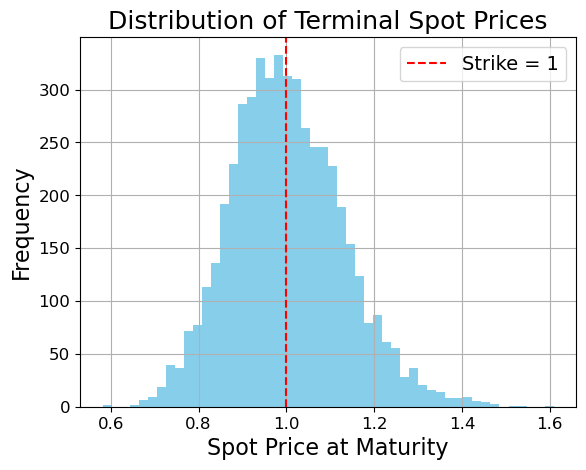

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Get terminal spot prices
terminal_spots = test_world.details.spot_all[:, -1]

# 2. Get payoffs
payoffs = test_result["payoff"].numpy()

# 3. Check how many are exactly -0 (or close)
n_zero_payoffs = np.sum(np.isclose(payoffs, 0))
print(f"Number of zero payoffs: {n_zero_payoffs} / {len(payoffs)}")

# 4. Plot histogram of terminal spot prices
plt.hist(terminal_spots, bins=50, color="skyblue")
plt.axvline(1.0, color="red", linestyle="--", label="Strike = 1")
plt.title("Distribution of Terminal Spot Prices")
plt.xlabel("Spot Price at Maturity")
plt.ylabel("Frequency")
plt.grid(True)
plt.legend()
plt.show()

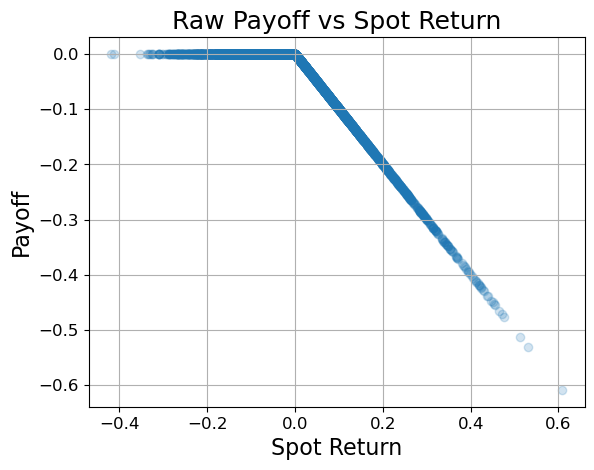

In [54]:
spot_return = test_world.details.spot_all[:, -1] - 1.0
payoff = test_result["payoff"].numpy()

import matplotlib.pyplot as plt
plt.scatter(spot_return, payoff, alpha=0.2)
plt.xlabel("Spot Return")
plt.ylabel("Payoff")
plt.title("Raw Payoff vs Spot Return")
plt.grid(True)
plt.show()

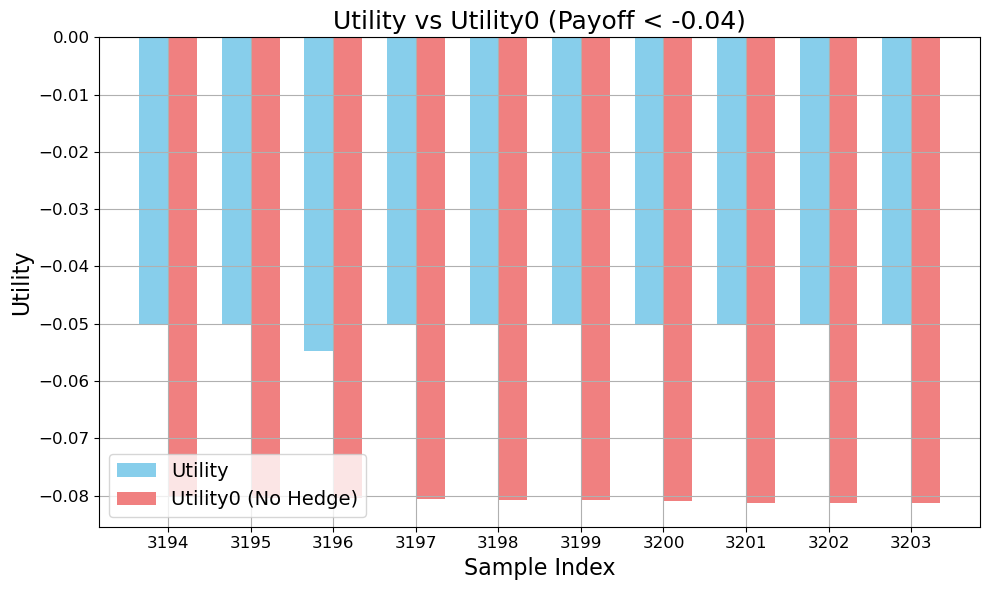

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Extract utility, utility0, and payoff
utility = test_result["utility"].numpy()
utility0 = test_result["utility0"].numpy()
payoff = test_result["payoff"].numpy()

# Find indices where payoff < 0 (i.e., short option was exercised)
negative_payoff_indices = np.where(payoff <= -0.04)[0]

# Take the first 10 of those
selected_indices = negative_payoff_indices[:10]
if len(selected_indices) == 0:
    print("No samples with payoff < -0.04 found.")
else:
    bar_width = 0.35
    indices = np.arange(len(selected_indices))

    plt.figure(figsize=(10, 6))
    plt.bar(indices, utility[selected_indices], width=bar_width, label='Utility', color='skyblue')
    plt.bar(indices + bar_width, utility0[selected_indices], width=bar_width, label='Utility0 (No Hedge)', color='lightcoral')

    plt.xlabel("Sample Index")
    plt.ylabel("Utility")
    plt.title("Utility vs Utility0 (Payoff < -0.04)")
    plt.xticks(indices + bar_width / 2, [str(i) for i in selected_indices])
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

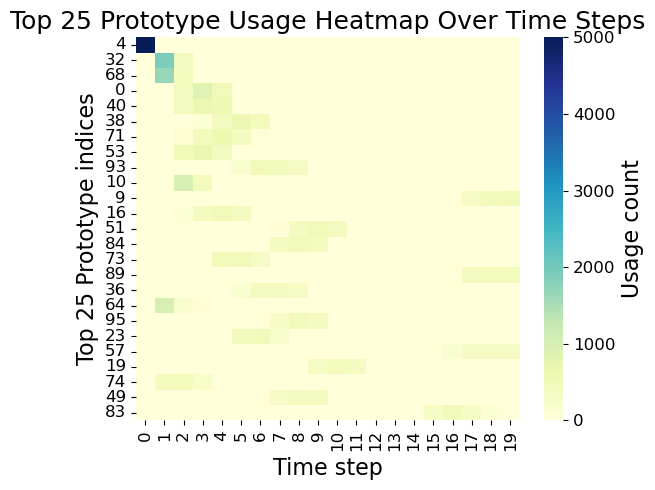

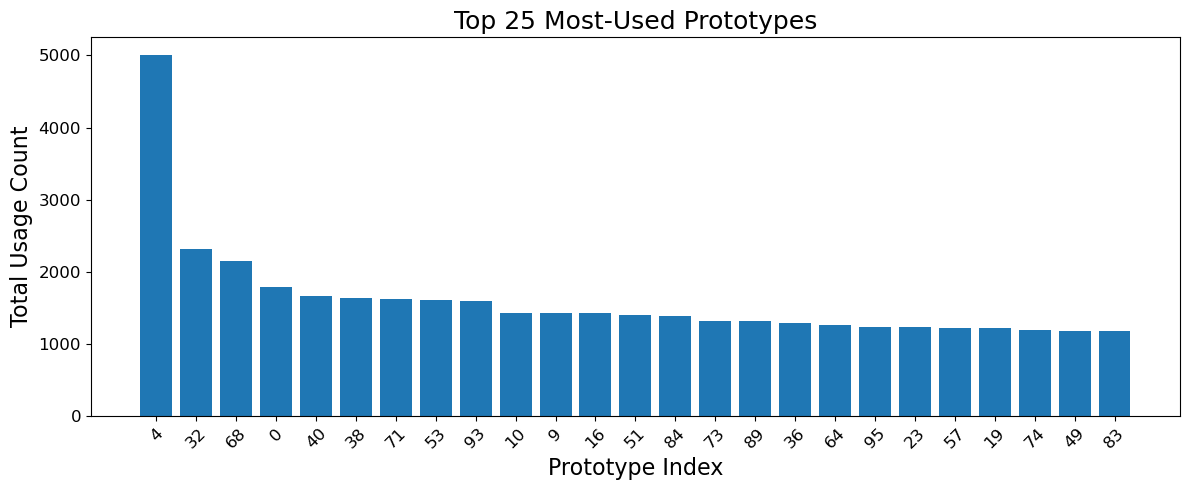

In [56]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# # Step 1: Run model on many test paths
# test_world = world.clone(samples=5000)
# result = gym(test_world.tf_data)

# # Step 2: Extract features from world and actions from result
price = test_world.data.features.per_step['price']       # shape: [5000, 20]
time_left = test_world.data.features.per_step['time_left']
actions = test_result['actions'].numpy().squeeze()            # shape: [5000, 20]

# Step 3: Build [B*T, 3] feature matrix in correct sorted order
B, T = price.shape
delta = np.concatenate([np.zeros((B, 1)), np.cumsum(actions[:, :-1], axis=1)], axis=1)
X = np.stack([delta, price, time_left], axis=2).reshape(-1, 3)  # [B*T, 3]

# Step 4: Apply saved scaler
with open(f"./prototypes_storage/prototypes_{n_prototypes}.pkl", "rb") as f:
    data = pickle.load(f)
scaler = data["scaler"]
X_scaled = scaler.transform(X)

# Step 5: Compute closest prototypes
proto_layer = gym.agent.proto_layer
x_tf = tf.convert_to_tensor(X_scaled, dtype=tf.float32)  # [B*T, 3]
x_exp = tf.expand_dims(x_tf, axis=1)                     # [B*T, 1, 3]
p_exp = tf.expand_dims(proto_layer.prototypes, axis=0)   # [1, P, 3]
distances = tf.reduce_sum((x_exp - p_exp)**2, axis=2)    # [B*T, P]
similarities = tf.nn.softmax(-distances, axis=1)         # [B*T, P]
closest = tf.argmax(similarities, axis=1).numpy()        # [B*T]

# Step 6: Reshape to [B, T] and count usage
closest_matrix = closest.reshape(B, T)                   # [B, T]
n_prototypes = proto_layer.prototypes.shape[0]
heatmap = np.zeros((n_prototypes, T))
for t in range(T):
    unique, counts = np.unique(closest_matrix[:, t], return_counts=True)
    heatmap[unique, t] = counts

# Step 7: Compute total usage per prototype and get top 25
totals = np.sum(heatmap, axis=1)                            # total use per prototype
top_indices = np.argsort(totals)[-25:][::-1]               # top 25 in descending order
filtered_heatmap = heatmap[top_indices]                     # filter rows
filtered_indices = top_indices                              # for labeling y-axis

# Step 8: Plot top 25 prototype usage
plt.figure(figsize=(6, 5))
sns.heatmap(filtered_heatmap, cmap="YlGnBu", cbar_kws={'label': 'Usage count'}, yticklabels=filtered_indices)
plt.xlabel("Time step")
plt.ylabel("Top 25 Prototype indices")
plt.title("Top 25 Prototype Usage Heatmap Over Time Steps")
plt.tight_layout()
plt.show()

## BAR PLOT : 

# Step 1: Compute total usage again
totals = np.sum(heatmap, axis=1)                             # [num_prototypes]
top_25_idx = np.argsort(totals)[-25:][::-1]                  # indices of top 25
top_25_vals = totals[top_25_idx]

# Step 2: Bar chart
plt.figure(figsize=(12, 5))
plt.bar(range(25), top_25_vals, tick_label=top_25_idx)
plt.xlabel("Prototype Index")
plt.ylabel("Total Usage Count")
plt.title("Top 25 Most-Used Prototypes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [57]:
import numpy as np
import pandas as pd
from IPython.display import display

# STEP 1: Get prototypes and actions directly from the model layer
proto_layer = gym.agent.proto_layer
prototypes_np = proto_layer.prototypes.numpy()
proto_actions_np = proto_layer.prototype_actions.numpy()

# STEP 2: Select top 10 prototype indices
top_10_idx = np.array(top_25_idx[:10], dtype=int)

# STEP 3: Extract prototype features and actions
top_10_prototypes = prototypes_np[top_10_idx]
top_10_actions = proto_actions_np[top_10_idx]

# STEP 4: Inverse scale features back to financial space
original_features = scaler.inverse_transform(top_10_prototypes)

# STEP 5: Build DataFrame
df = pd.DataFrame(original_features, columns=["delta", "price", "time_left"])
df["action"] = top_10_actions[:, 0]
df["prototype_index"] = top_10_idx

# Reorder columns for readability
df = df[["prototype_index", "delta", "price", "time_left", "action"]]

# STEP 6: Display
display(df.style.set_caption("Top 10 Most-Used Prototypes with Features and Actions"))

,prototype_index,delta,price,time_left,action
0,4,0.000000,1.000000,0.400000,0.778570
1,32,0.557481,0.993379,0.380000,-0.181702
2,68,0.557481,1.021386,0.380000,0.004696
3,0,0.597390,1.003807,0.340000,-0.219786
4,40,0.661614,1.037527,0.340000,0.214858
5,38,0.745616,1.059126,0.300000,0.056939
6,71,0.367757,0.971579,0.320000,-0.259499
7,53,0.473444,1.009338,0.340000,0.394193
8,93,0.264993,0.949616,0.260000,-0.211148
9,10,0.463691,0.977794,0.360000,-0.471911


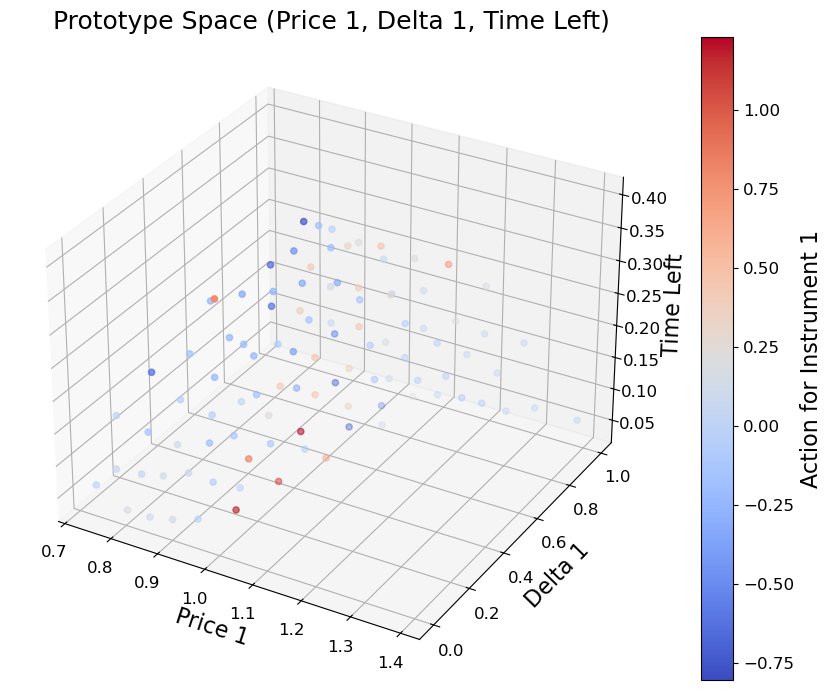

In [58]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load prototype data
with open(f"./prototypes_storage/prototypes_{n_prototypes}.pkl", "rb") as f:
    data = pickle.load(f)

prototypes = data["prototypes"]        # shape (1000, 5)
proto_actions = gym.agent.proto_layer.prototype_actions.numpy()  # shape (1000, 2)

# 1. Reverse scale: get interpretable values
prototypes_raw = scaler.inverse_transform(prototypes)  # shape: [N, 5]

# 2. Select interpretable features
price_1 = prototypes_raw[:, 1]
delta_1 = prototypes_raw[:, 0]
time_left = prototypes_raw[:, 2]
action_1 = proto_actions[:, 0]  # Action for instrument 1

# 3. Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(price_1, delta_1, time_left, c=action_1, cmap='coolwarm', s=20)

ax.set_xlabel("Price 1")
ax.set_ylabel("Delta 1")
ax.set_zlabel("Time Left")
fig.colorbar(p, ax=ax, label="Action for Instrument 1")
ax.set_title("Prototype Space (Price 1, Delta 1, Time Left)")

plt.tight_layout()
plt.show()

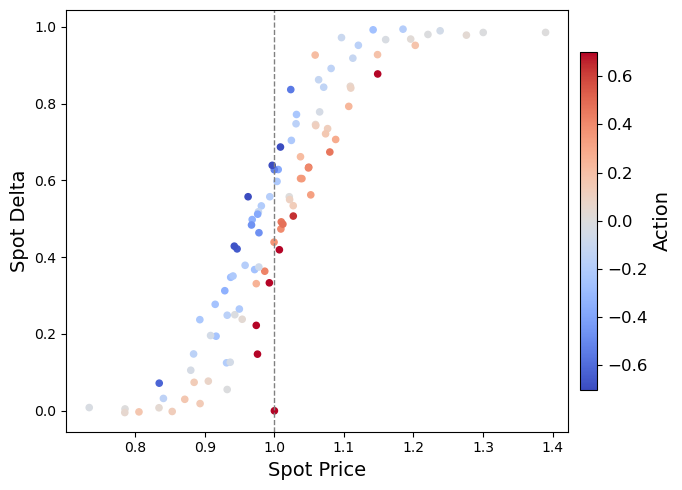

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Set symmetric color limits around 0
abs_max = np.max(np.abs(action_1))
symmetric_limit = np.ceil(abs_max * 5) / 10
norm = TwoSlopeNorm(vmin=-symmetric_limit, vcenter=0.0, vmax=symmetric_limit)

# 2D scatter plot
plt.figure(figsize=(7, 5))
sc = plt.scatter(price_1, delta_1, c=action_1, cmap='coolwarm', norm=norm, s=20)

# Axis labels and styling
plt.xlabel("Spot Price", fontsize=14)
plt.ylabel("Spot Delta", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Add vertical dashed line at price = 1.0
plt.axvline(x=1.0, color='gray', linestyle='--', linewidth=1)

# Colorbar
cbar = plt.colorbar(sc, shrink=0.8, pad=0.02)
cbar.set_label("Action", fontsize=14)

plt.tight_layout()
plt.show()

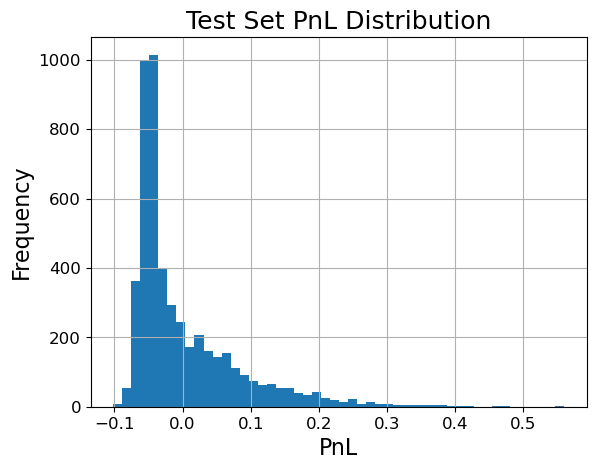

In [60]:
## PNL PLOT

plt.hist(test_result["pnl"].numpy(), bins=50)
plt.title("Test Set PnL Distribution")
plt.xlabel("PnL")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [61]:
test_result["pnl"].numpy().mean()

0.0016229034

In [62]:
import numpy as np

utility = test_result["utility"].numpy()
utility0 = test_result["utility0"].numpy()

# Count how many times utility > utility0
n_better = np.sum(utility > utility0)
total = len(utility)

print(f"Utility is higher than Utility0 in {n_better} out of {total} samples ({n_better / total:.2%})")

Utility is higher than Utility0 in 1973 out of 5000 samples (39.46%)


Running strategies ...done
Running tensorflow to compute utility of BS strategy ...done; result -0.0516349
Rendering now. Stand by.


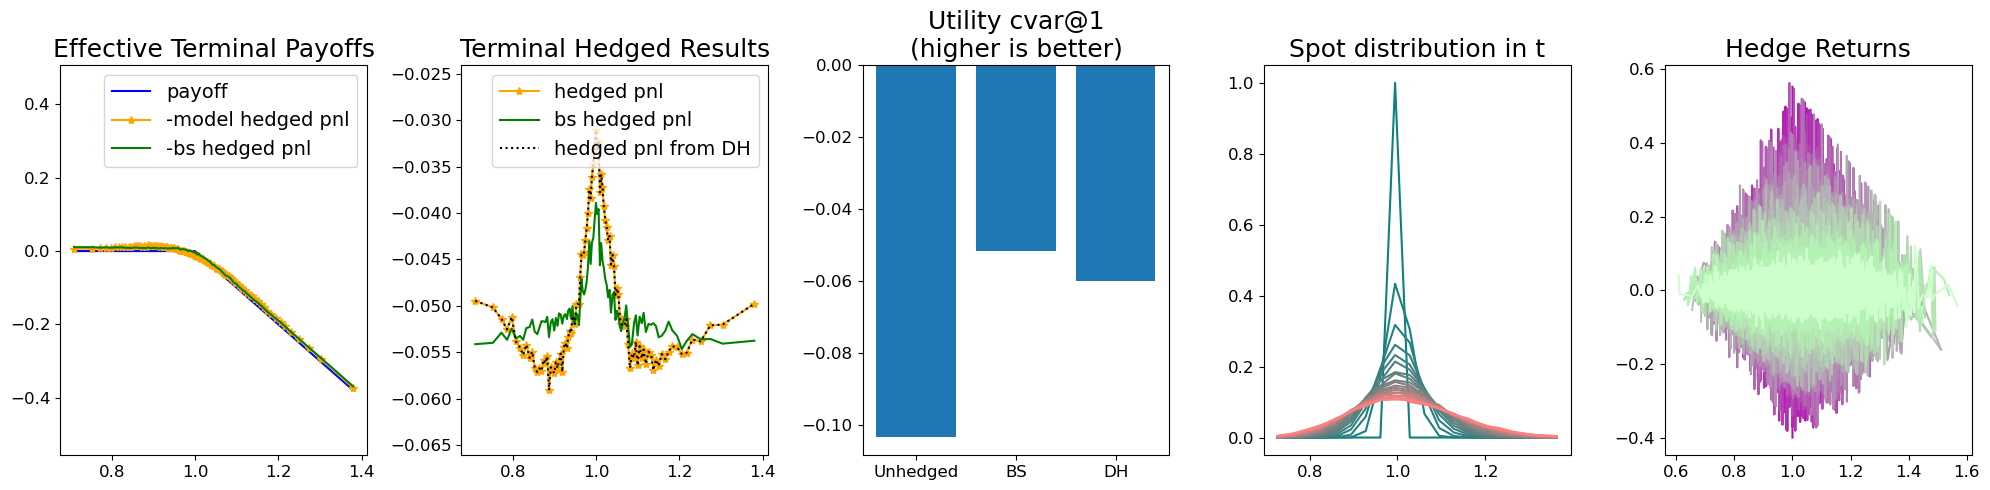

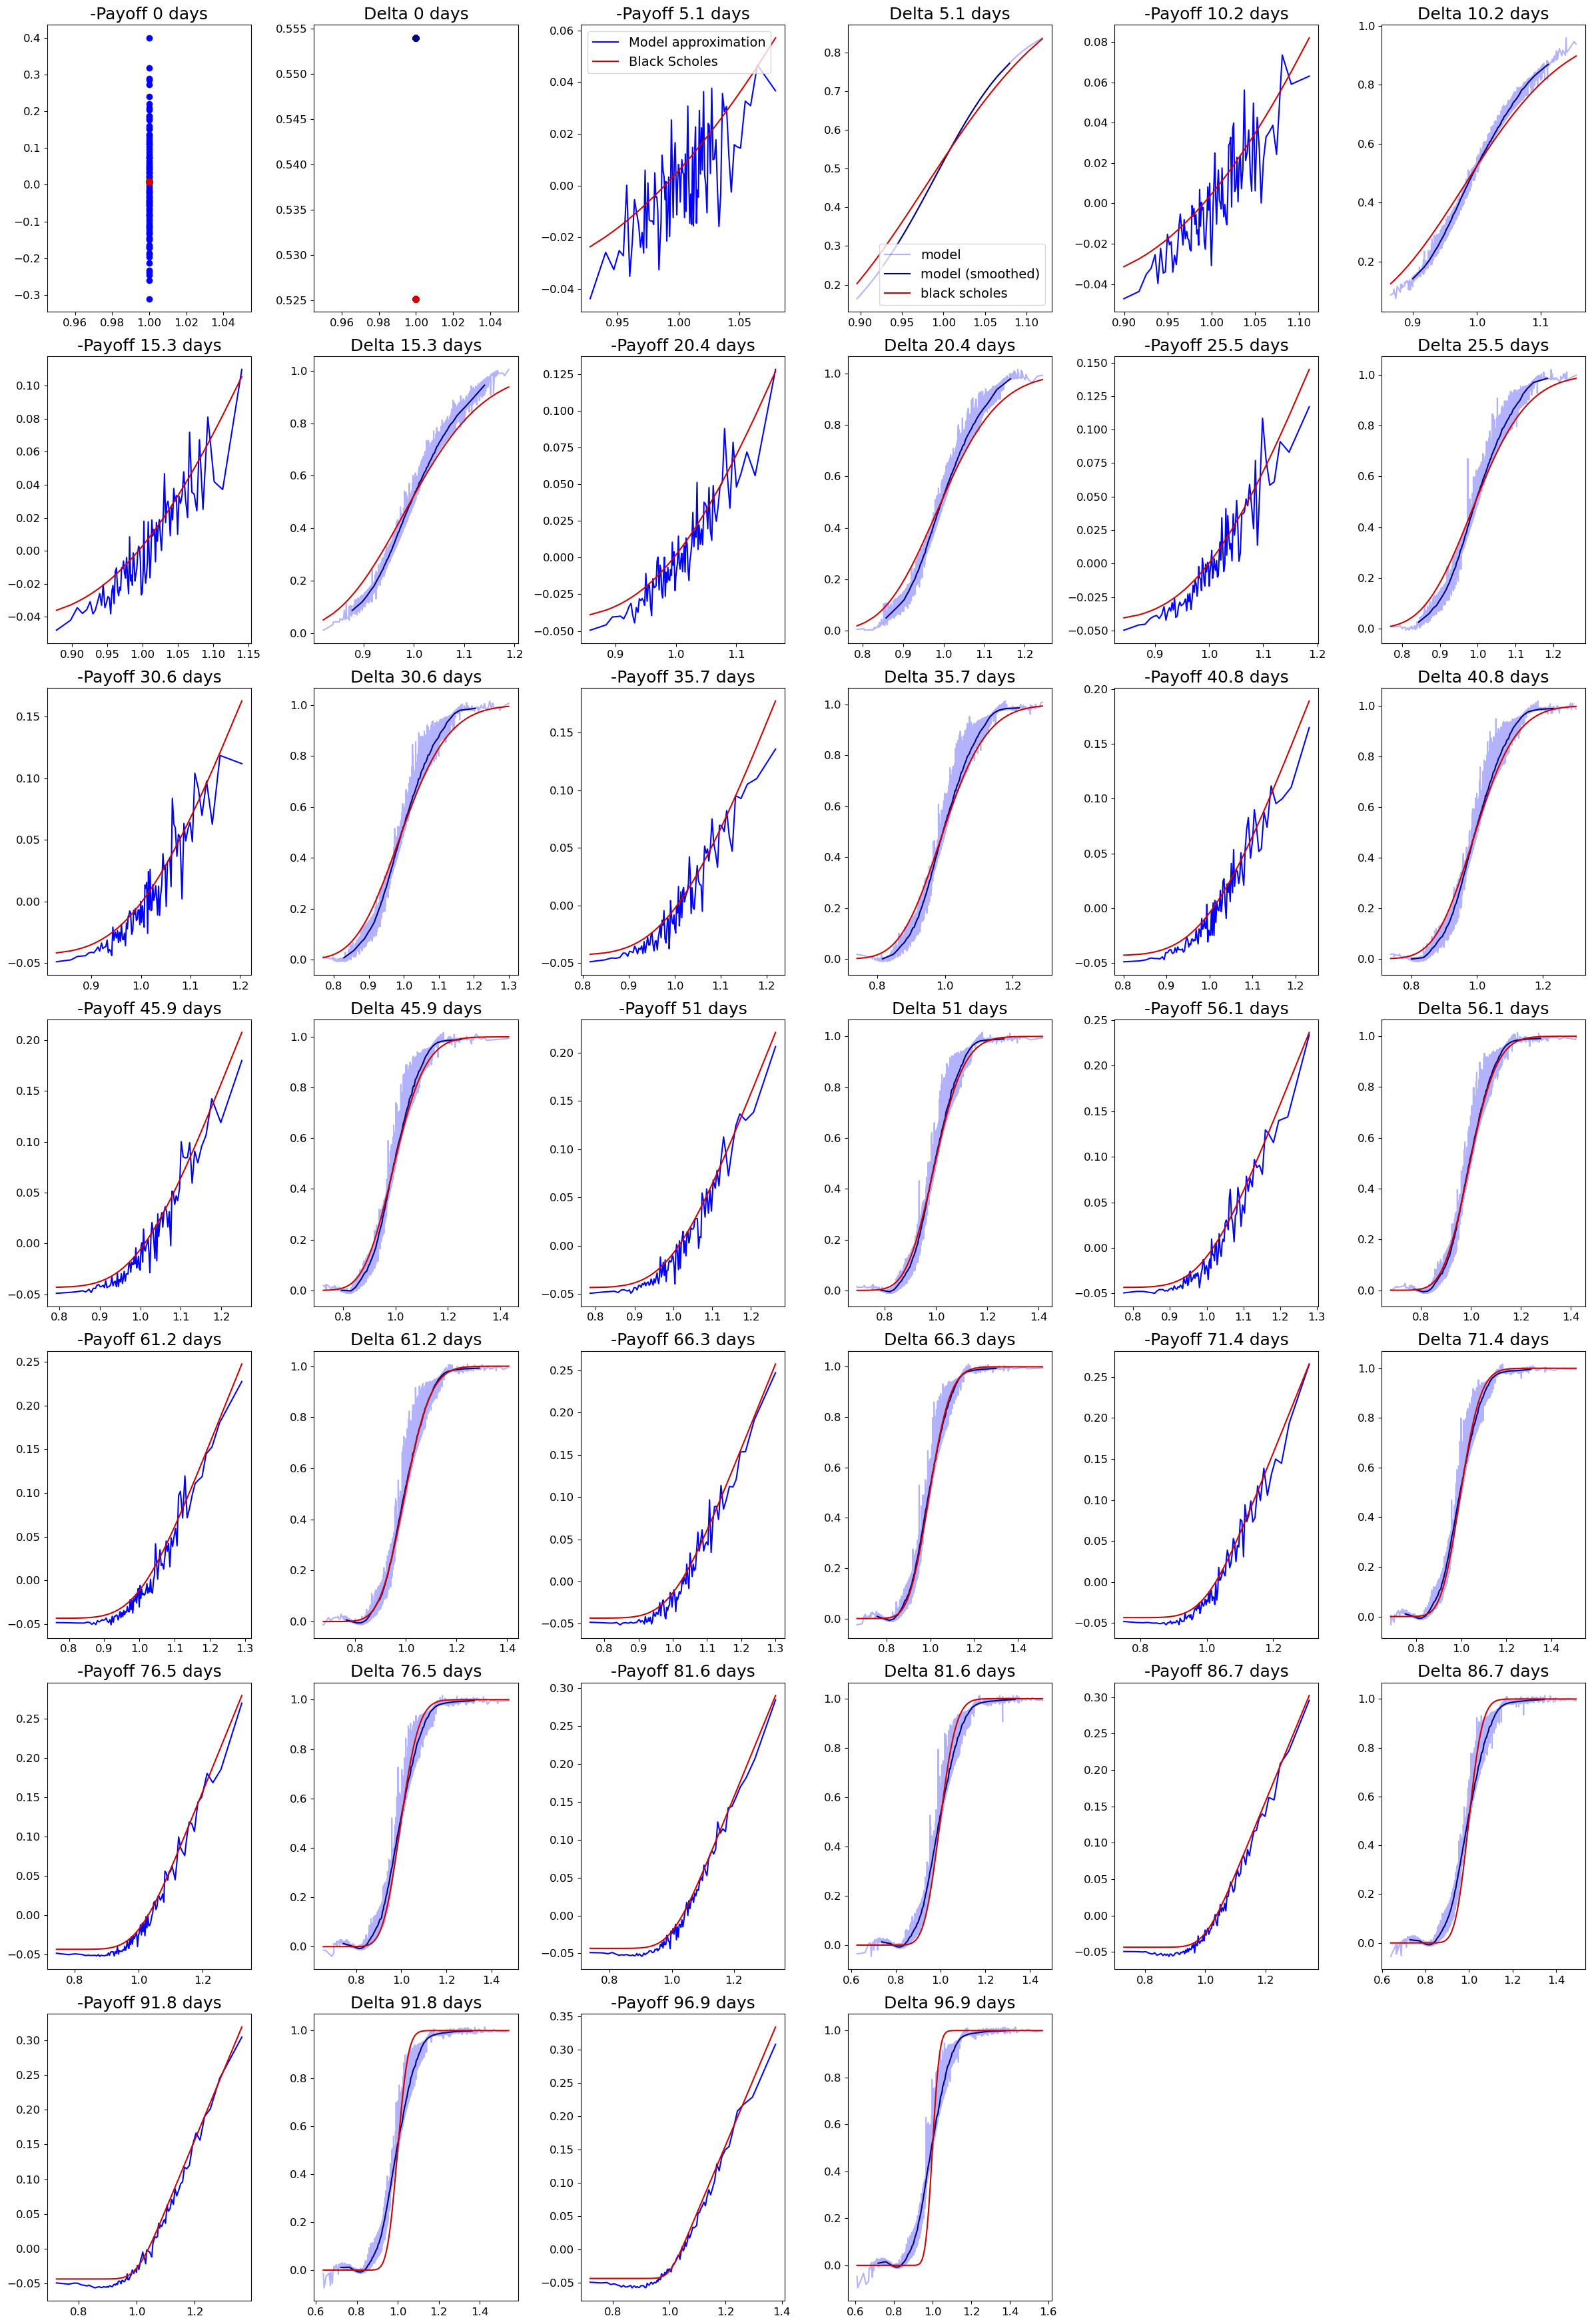

In [63]:
import deephedging.plot_bs_hedge as plot_bs_hedge
plot_bs_hedge.plot_blackscholes( world, gym, config )

In [ ]:
# # 1. Generate 5000 new test samples from same world
# test_world = world.clone(samples=10000)
# test_result = gym(test_world.tf_data)
# test_result_vanilla = gym_vanilla(test_world.tf_data)

In [64]:
print("PROTOTYPE-BASED STATS : ")
print("Mean Utility (unhedged):", test_result["utility0"].numpy().mean())
print("Mean Utility (hedged):", test_result["utility"].numpy().mean())
print("payoff", test_result["payoff"].numpy().mean())
print("gains", test_result["gains"].numpy().mean())
print("pnl", test_result["pnl"].numpy().mean())
print("")

print("VANILLA STATS : ")
print("Mean Utility (unhedged):", test_result_vanilla["utility0"].numpy().mean())
print("Mean Utility (hedged):", test_result_vanilla["utility"].numpy().mean())
print("payoff", test_result_vanilla["payoff"].numpy().mean())
print("gains", test_result_vanilla["gains"].numpy().mean())
print("pnl", test_result_vanilla["pnl"].numpy().mean())

PROTOTYPE-BASED STATS : 
Mean Utility (unhedged): -0.10387109
Mean Utility (hedged): -0.059773818
payoff -0.051934138
gains -0.05067507
pnl 0.0016229034

VANILLA STATS : 
Mean Utility (unhedged): -0.10387007
Mean Utility (hedged): -0.05816568
payoff -0.051934138
gains -0.050697383
pnl 0.0016216446


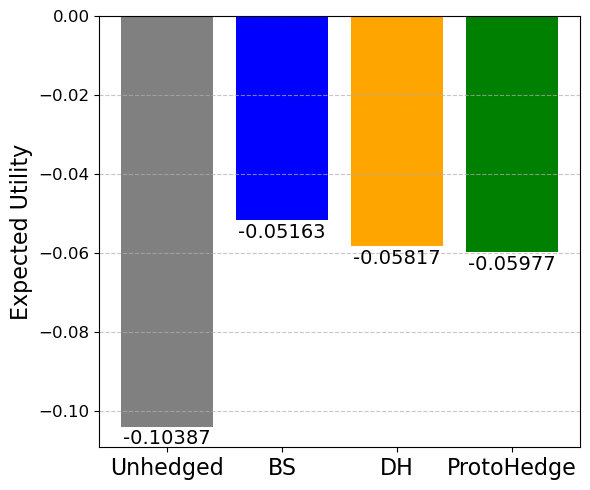

In [70]:
import matplotlib.pyplot as plt

# Utilities
utilities = {
    'Unhedged': test_result_vanilla["utility0"].numpy().mean(),
    'BS': -0.0516349,
    'DH': test_result_vanilla["utility"].numpy().mean(),
    'ProtoHedge': test_result["utility"].numpy().mean()
}

labels = list(utilities.keys())
values = list(utilities.values())
colors = ['gray', 'blue', 'orange', 'green']

# Plot
plt.figure(figsize=(6, 5))
bars = plt.bar(labels, values, color=colors)

plt.ylabel('Expected Utility', fontsize=16)
plt.xticks(fontsize=16)
# plt.title('Expected Utility Comparison (CVaR@50%) in Black-Scholes World')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add black text below the top of each bar
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, val - 0.0055, f"{val:.5f}",
             ha='center', va='bottom', color='black', fontsize=14)

plt.tight_layout()
plt.show()

# Stochastic Volatility World

## Vanilla DH - No intial Delta

Deep Hedging AI says hello  ... 

## Deep Hedging in a simple Stochastic Volatility World

Initializing training at 2025-07-24 14:59:04: gym with 1004 trainable weights compiled. Took 1s
Agent is using 1002 weights: 1002 for the main agent per step.
 Features available per time step:     action, call_delta, call_price, call_vega, cost, cost_v, delta, ivol, lbnd_a, pnl, price, spot, sqrt_time_left, time_left and ubnd_a
 Features used per time step:          delta, price and time_left
Monetary utility cvar@1 is using 1 weight
 Features available: call_delta, call_price, call_vega, cost, cost_v, ivol, lbnd_a, price, spot, sqrt_time_left, time_left and ubnd_a
 Features used:      -
Caching enabled @ '/Users/lisafaloughi/Desktop/DeepHedging/deephedging/notebooks/.deephedging_cache/254707f31dc64df7e1ec8dc97ccac7b6c4a94d484b844f0b.pck'
Cache successfully loaded. Current epoch: 800
Nothing to do: cached model loaded from /Users/lisafaloughi/Desktop/DeepHedging/deephedging/notebooks/.deephedging_cache/254707f31dc64df7e1ec8dc97ccac7b6c4a94d484b844f0b.pck was trained for 800 epochs; yo

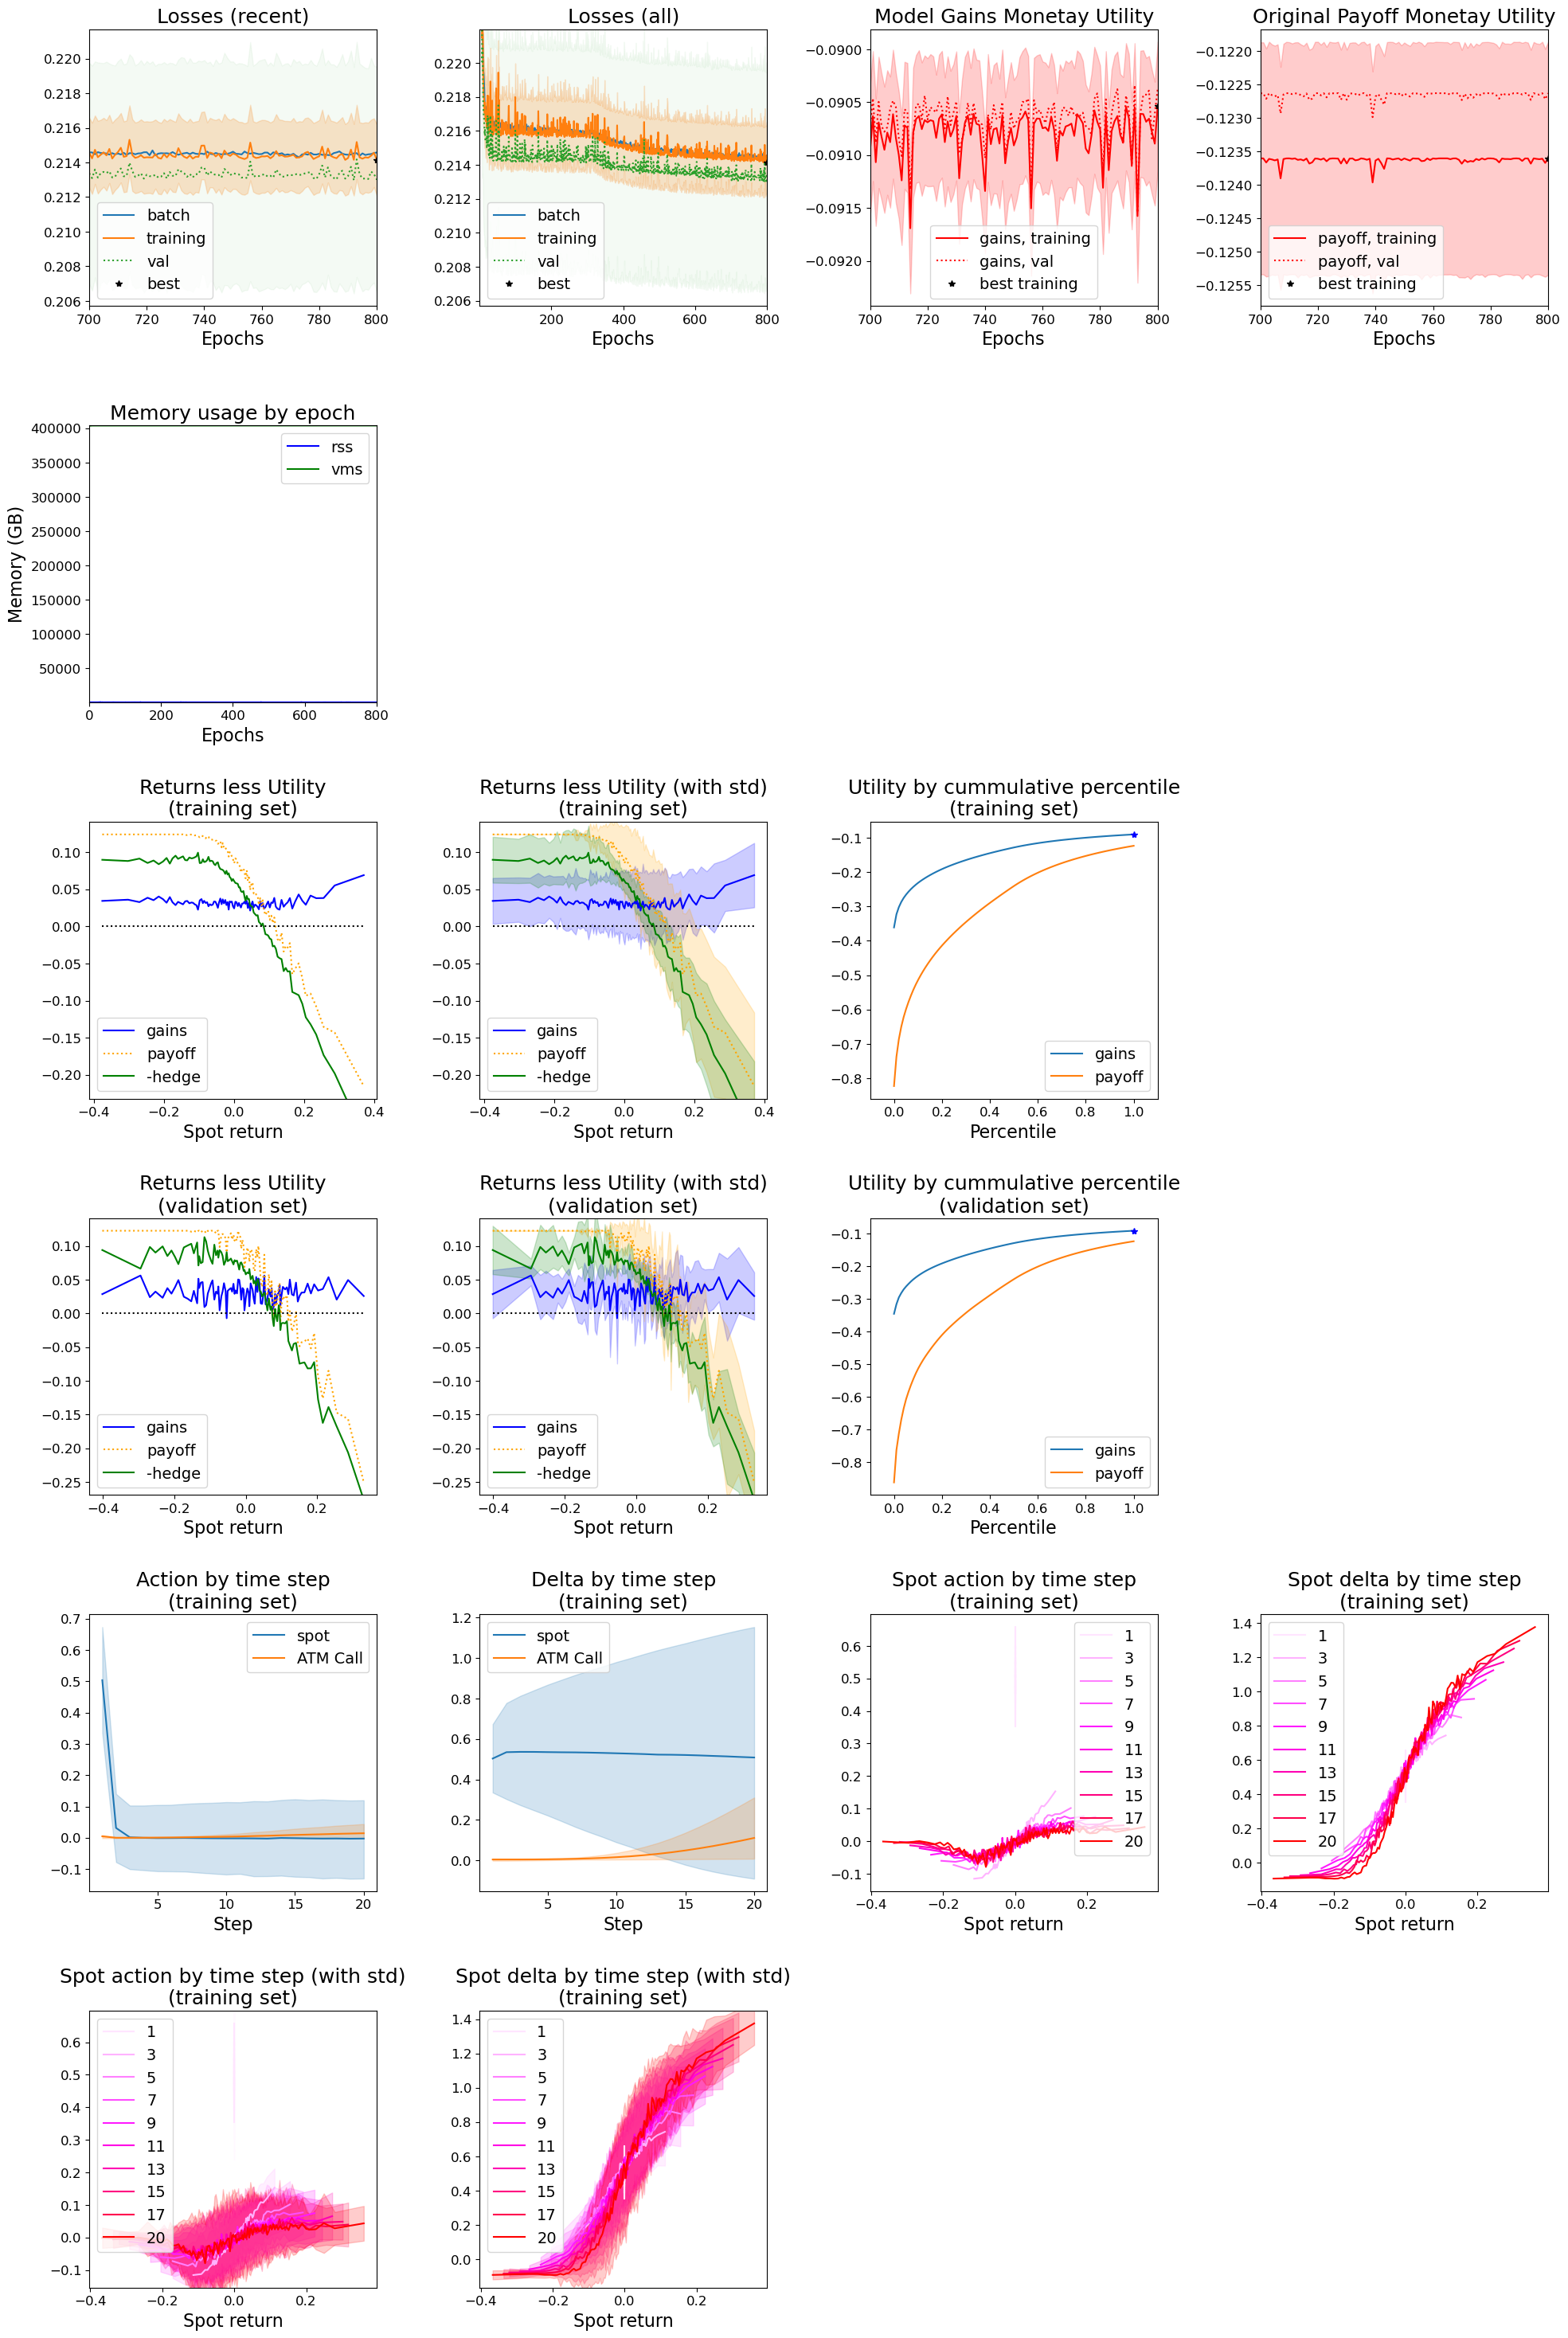

Training 800/800 epochs; 1004 weights; 10000 samples; 1000 validation samples batch size 32 | initial loss 0.644496 (0.00910156), training 0.214142 (0.00206014), best 0.214142 (0.00910156), batch 0.214575, val 0.213005 (0.00651256); best epoch 800, last cached 800 | memory used: rss 148.438M, vms 404023M | time elapsed 58:42; time per epoch 4s; estimated time remaining 0s | current time: 2025-07-24 14:59:07                        
 Status: Cached model already sufficiently trained.
 Weights set to best epoch: 800
 State of training until epoch 800 cached into /Users/lisafaloughi/Desktop/DeepHedging/deephedging/notebooks/.deephedging_cache/254707f31dc64df7e1ec8dc97ccac7b6c4a94d484b844f0b.pck
 Time: 2025-07-24 14:59:08
Training terminated. Total time taken 3s
Keys of the dictionary returned by the gym:  odict_keys(['loss', 'utility', 'utility0', 'gains', 'payoff', 'pnl', 'cost', 'actions'])
Config usage report
config.gym.agent.init_delta['active'] = False # Whether or not to train in add

In [71]:
print("Deep Hedging AI says hello  ... ", end='')
from cdxbasics.config import Config
from deephedging.trainer import train
from deephedging.gym import VanillaDeepHedgingGym
from deephedging.world import SimpleWorld_Spot_ATM
import tensorflow as tf

from IPython.display import display, Markdown

# see print of the config below for numerous options
config = Config()
# world
config.world.samples = 10000
config.world.steps = 20
config.world.black_scholes = False
# gym
config.gym.objective.utility = "cvar"
config.gym.objective.lmbda = 1.
config.gym.agent.network.depth = 3
config.gym.agent.network.activation = "softplus"
# trainer
config.trainer.train.optimizer.name = "adam"
config.trainer.train.optimizer.learning_rate = 0.001
config.trainer.train.optimizer.clipvalue = 1.
config.trainer.train.optimizer.global_clipnorm = 1.
config.trainer.train.batch_size = None
config.trainer.train.epochs = 800
config.trainer.caching.mode = "on"
config.trainer.train.run_eagerly = None
config.trainer.visual.epoch_refresh = 5
config.trainer.visual.confidence_pcnt_lo = 0.25
config.trainer.visual.confidence_pcnt_hi = 0.75

# Disable initial delta
config.gym.agent.init_delta.active = False

display(Markdown("## Deep Hedging in a simple Stochastic Volatility World"))

# create world
world  = SimpleWorld_Spot_ATM( config.world )
val_world  = world.clone(samples=world.nSamples//10)

# create training environment
tf.debugging.enable_check_numerics()
vanilla_stoch_gym = VanillaDeepHedgingGym( config.gym )

# create training environment
train( gym=vanilla_stoch_gym, world=world, val_world=val_world, config=config.trainer )
r = vanilla_stoch_gym(world.tf_data)
print("Keys of the dictionary returned by the gym: ", r.keys())

print("=========================================")
print("Config usage report")
print("=========================================")
print( config.usage_report() )
config.done()

## Prototype-based Stochastic Volatility World

Deep Hedging AI says hello  ... 

## Deep Hedging in a simple Stochastic Volatility World

Initializing training at 2025-07-24 14:59:17: gym with 1007 trainable weights compiled. Took 1s
ProtoAgent using 1005 trainable weights for 2 instruments.
Features used: delta, price and time_left
Monetary utility cvar@1 is using 1 weight
 Features available: call_delta, call_price, call_vega, cost, cost_v, ivol, lbnd_a, price, spot, sqrt_time_left, time_left and ubnd_a
 Features used:      -
Caching enabled @ '/Users/lisafaloughi/Desktop/DeepHedging/deephedging/notebooks/.deephedging_cache/proto_stoch_500_weights_trained_v1/ed0b40232c02cb2af48f04145cd0bab0e31b1f02f19a65f6.pck'
Cache successfully loaded. Current epoch: 800
Nothing to do: cached model loaded from /Users/lisafaloughi/Desktop/DeepHedging/deephedging/notebooks/.deephedging_cache/proto_stoch_500_weights_trained_v1/ed0b40232c02cb2af48f04145cd0bab0e31b1f02f19a65f6.pck was trained for 800 epochs; you have asked to train for 800 epochs. If you want to force training: raise number of epochs or turn off caching.
Plotting results 

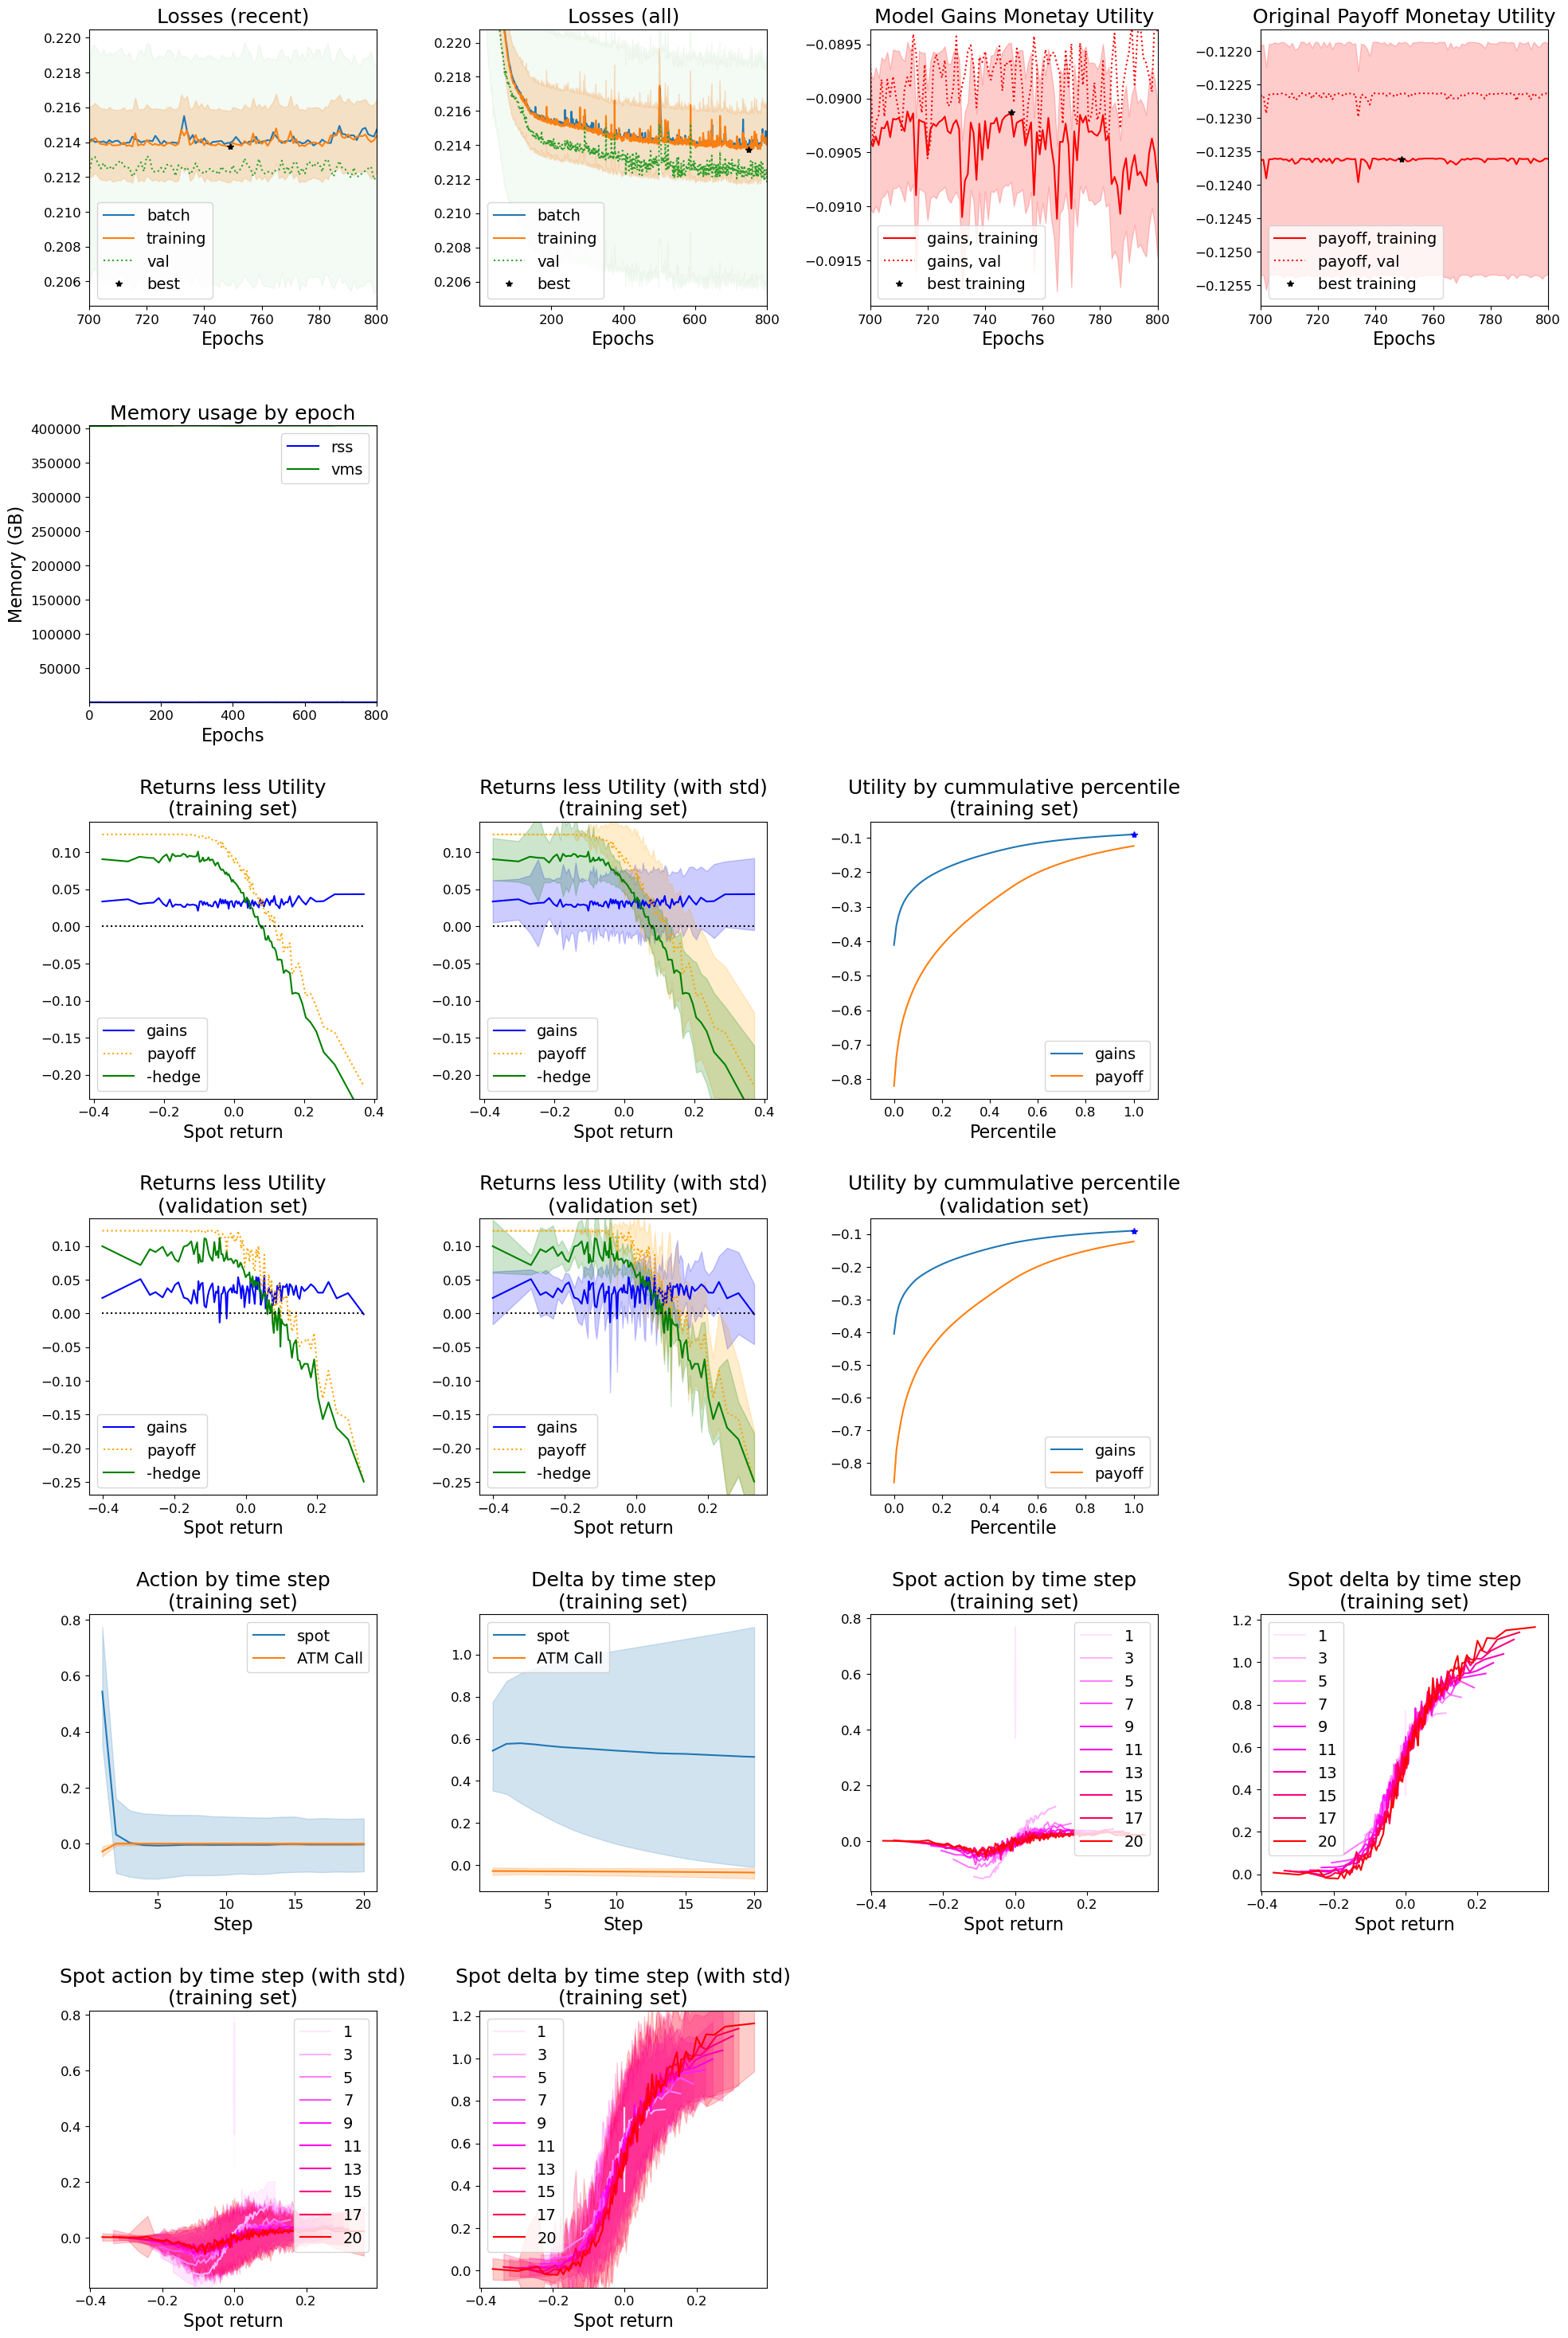

Training 800/800 epochs; 1007 weights; 10000 samples; 1000 validation samples batch size 32 | initial loss 0.793866 (0.011209), training 0.214383 (0.00205633), best 0.213738 (0.011209), batch 0.214724, val 0.212036 (0.00649992); best epoch 749, last cached 800 | memory used: rss 350.844M, vms 404623M | time elapsed 2:21:47; time per epoch 10s; estimated time remaining 0s | current time: 2025-07-24 14:59:19                        
 Status: Cached model already sufficiently trained.
 Weights set to best epoch: 749
 State of training until epoch 800 cached into /Users/lisafaloughi/Desktop/DeepHedging/deephedging/notebooks/.deephedging_cache/proto_stoch_500_weights_trained_v1/ed0b40232c02cb2af48f04145cd0bab0e31b1f02f19a65f6.pck
 Time: 2025-07-24 14:59:20
Training terminated. Total time taken 3s
Keys of the dictionary returned by the gym:  odict_keys(['loss', 'utility', 'utility0', 'gains', 'payoff', 'pnl', 'cost', 'actions'])
Config usage report
config.gym.agent.environment['hard_clip'] = 

In [72]:
print("Deep Hedging AI says hello  ... ", end='')
import pickle
from deephedging.gym import VanillaDeepHedgingGym
from deephedging.trainer import train
from deephedging.world import SimpleWorld_Spot_ATM
from cdxbasics.config import Config
from IPython.display import display, Markdown
# ============================
# 1. Load configuration
config = Config()

n_prototypes = 500

# 2. World setup
config.world.samples = 10000
config.world.steps = 20
config.world.black_scholes = False

# 3. Gym setup with ProtoAgent
config.gym.agent.agent_type = "protopnet"  # Tells AgentFactory to use ProtoAgent
config.gym.agent.features = ["price", "delta", "time_left"]  # Must match prototype dimensions
config.gym.agent.prototype_path = f"./prototypes_storage/prototypes_stochastic_{n_prototypes}.pkl"

config.gym.objective.utility = "cvar"
config.gym.objective.lmbda = 1.

# 4. Load saved prototypes (used inside ProtoPNetLayer)
with open(f"./prototypes_storage/prototypes_stochastic_{n_prototypes}.pkl", "rb") as f:
    prototypes = pickle.load(f)

# 5. Trainer config
config.trainer.train.epochs = 800
config.trainer.caching.directory = f"./.deephedging_cache/proto_stoch_{n_prototypes}_weights_trained_v1"

config.trainer.caching.mode = "on"  # Important to avoid reusing old cache
config.trainer.visual.epoch_refresh = 5

# trainer
config.trainer.train.optimizer.name = "adam"
config.trainer.train.optimizer.learning_rate = 0.001
config.trainer.train.optimizer.clipvalue = 1.
config.trainer.train.optimizer.global_clipnorm = 1.
config.trainer.train.batch_size = None
config.trainer.visual.confidence_pcnt_lo = 0.25
config.trainer.visual.confidence_pcnt_hi = 0.75

display(Markdown("## Deep Hedging in a simple Stochastic Volatility World"))

# 6. Build world & val_world
world = SimpleWorld_Spot_ATM(config.world)
val_world = world.clone(samples=world.nSamples // 10)

# 7. Create the gym (automatically uses ProtoAgent via AgentFactory)
gym = VanillaDeepHedgingGym(config.gym)

# 8. Train the model using the prototype-based agent
train(gym=gym, world=world, val_world=val_world, config=config.trainer)

r = gym(world.tf_data)
print("Keys of the dictionary returned by the gym: ", r.keys())

print("=========================================")
print("Config usage report")
print("=========================================")
print( config.usage_report() )
config.done()

## Stochastic Analysis

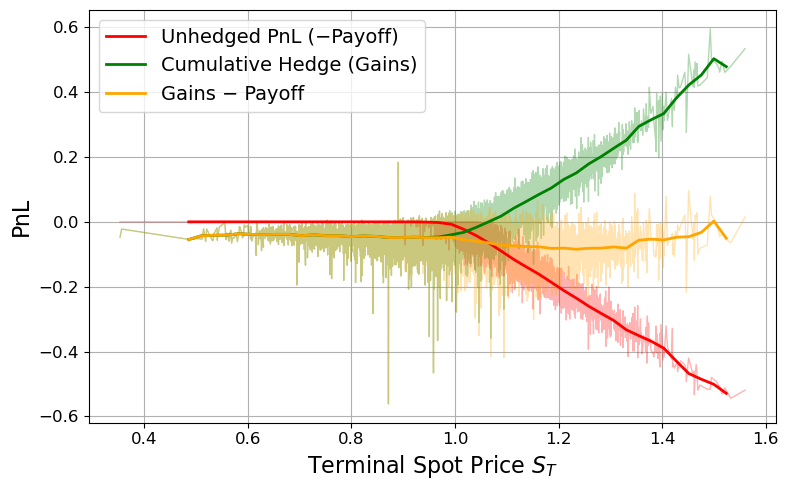

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from deephedging.base import npCast

# Step 1: Extract data
spotT = world.details.spot_all[:, -1]
payoff = npCast(r["payoff"])
dh_pnl = npCast(r["pnl"])
terminal_pnl = payoff + dh_pnl

# Step 2: Define bins and compute bin centers
n_bins = 50
bins = np.linspace(spotT.min(), spotT.max(), n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Step 3: Initialize arrays
payoff_binned = np.zeros(n_bins)
gain_binned = np.zeros(n_bins)
total_binned = np.zeros(n_bins)

# Step 4: Bin data
for i in range(n_bins):
    mask = (spotT >= bins[i]) & (spotT < bins[i+1])
    if np.any(mask):
        payoff_binned[i] = np.mean(payoff[mask])
        gain_binned[i] = np.mean(dh_pnl[mask])
        total_binned[i] = np.mean(terminal_pnl[mask])
    else:
        payoff_binned[i] = np.nan
        gain_binned[i] = np.nan
        total_binned[i] = np.nan

# Step 5: Sort raw data by spotT for raw (transparent) curves
ixs = np.argsort(spotT)
sorted_spotT = spotT[ixs]
sorted_payoff = payoff[ixs]
sorted_gain = dh_pnl[ixs]
sorted_total = terminal_pnl[ixs]

# Step 6: Plot both raw and binned versions
plt.figure(figsize=(8, 5))

# Plot raw data (faint, no legend)
plt.plot(sorted_spotT, sorted_payoff, label="_nolegend_", color="red", alpha=0.3, linewidth=1)
plt.plot(sorted_spotT, sorted_gain, label="_nolegend_", color="green", alpha=0.3, linewidth=1)
plt.plot(sorted_spotT, sorted_total, label="_nolegend_", color="orange", alpha=0.3, linewidth=1)

# Plot binned (smoothed) curves with legend
plt.plot(bin_centers, payoff_binned, label="Unhedged PnL (−Payoff)", color="red", linewidth=2)
plt.plot(bin_centers, gain_binned, label="Cumulative Hedge (Gains)", color="green", linewidth=2)
plt.plot(bin_centers, total_binned, label="Gains − Payoff", color="orange", linewidth=2)

# Labels and formatting
plt.xlabel("Terminal Spot Price $S_T$")
plt.ylabel("PnL")
# plt.title("Terminal Hedged PnL vs Spot Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

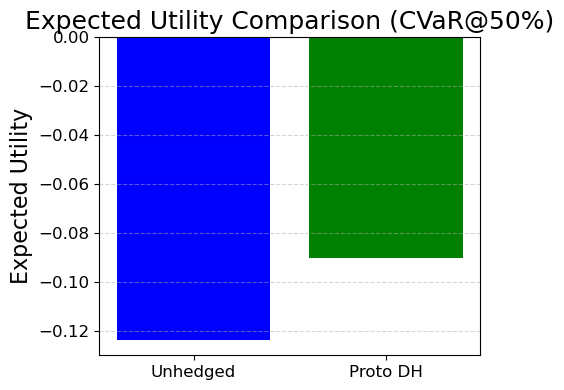

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from deephedging.base import npCast

# Extract utilities
utility = npCast(r["utility"])     # With hedge
utility0 = npCast(r["utility0"])   # Without hedge
P = world.sample_weights           # Sample weights

# Expected utility (CVaR) values
mean_util = np.sum(P * utility) / np.sum(P)
mean_util0 = np.sum(P * utility0) / np.sum(P)

# Bar plot
plt.figure(figsize=(5, 4))
plt.bar(["Unhedged", "Proto DH"], [mean_util0, mean_util], color=["blue", "green"])
plt.ylabel("Expected Utility")
plt.title("Expected Utility Comparison (CVaR@50%)")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Stochastic Volatility: Inference


In [75]:
import tensorflow as tf
import numpy as np
from pickle import load
import random

# Set global seeds (recommended for full reproducibility)
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# 1. Select agent and load scaler
agent = gym.agent
with open(f"./prototypes_storage/prototypes_stochastic_{n_prototypes}.pkl", "rb") as f:
    data = load(f)
scaler = data["scaler"]

# 2. Generate 1 new reproducible test path
test_world = world.clone(samples=5000, seed=seed)
test_result = gym(test_world.tf_data)

In [76]:
path_num = -100

test_result["utility0"][path_num], test_result["utility"][path_num]

(<tf.Tensor: shape=(), dtype=float32, numpy=-0.5182756>,
 <tf.Tensor: shape=(), dtype=float32, numpy=-0.06706937>)

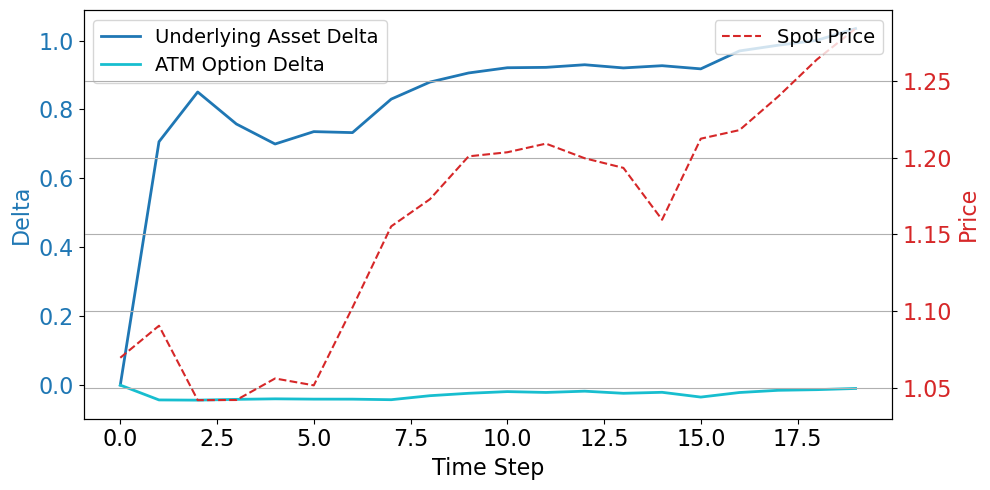

In [93]:
import matplotlib.pyplot as plt
import numpy as np

# 3. Extract per-step inputs (shape: [20, 2] for price and delta)
price = test_world.data.features.per_step['price'][path_num]          # [20, 2]
time_left = test_world.data.features.per_step['time_left'][path_num]  # [20,]
actions = test_result['actions'][path_num]                            # [20, 2]
delta = np.cumsum(actions, axis=0) - actions                   # [20, 2]

# 4. Build input: [delta_1, delta_2, price_1, price_2, time_left]
delta_1 = delta[:, 0]
delta_2 = delta[:, 1]
price_1 = price[:, 0]
price_2 = price[:, 1]
X = np.stack([delta_1, delta_2, price_1, price_2, time_left], axis=1)   # shape (20, 5)

# Use actual data extracted from your notebook
steps = np.arange(20)

# Replace these with the actual extracted values from path -10
# These should already be defined:
# delta_1, delta_2, price_1, price_2

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

# Left Y-axis: Delta
ax1.set_xlabel('Time Step', fontsize=16)
ax1.set_ylabel('Delta', color='tab:blue', fontsize=16)
ax1.plot(steps, delta_1, label='Underlying Asset Delta', color='tab:blue', linewidth=2)
ax1.plot(steps, delta_2, label='ATM Option Delta', color='tab:cyan', linewidth=2)
ax1.tick_params(axis='y',labelsize=16, labelcolor='tab:blue')
ax1.tick_params(axis='x', labelsize=16)  # Add this line

ax1.legend(loc='upper left')

# Right Y-axis: Price
ax2 = ax1.twinx()
ax2.set_ylabel('Price', color='tab:red',fontsize=16)
ax2.plot(steps, price_1, label='Spot Price', color='tab:red', linestyle='--')
# ax2.plot(steps, price_2, label='Price 2', color='tab:pink', linestyle='--')
ax2.tick_params(axis='y', labelcolor='tab:red', labelsize=16)
ax2.legend(loc='upper right')

# plt.title('Delta and Price Evolution Over Time (Single Path)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [78]:
# 3. Extract per-step inputs (shape: [20, 2] for price and delta)
price = test_world.data.features.per_step['price'][path_num]          # [20, 2]
time_left = test_world.data.features.per_step['time_left'][path_num]  # [20,]
actions = test_result['actions'][path_num]                            # [20, 2]
delta = np.cumsum(actions, axis=0) - actions                   # [20, 2]

# 4. Build input: [delta_1, delta_2, price_1, price_2, time_left]
delta_1 = delta[:, 0]
delta_2 = delta[:, 1]
price_1 = price[:, 0]
price_2 = price[:, 1]
X = np.stack([delta_1, delta_2, price_1, price_2, time_left], axis=1)   # shape (20, 5)

# 5. Scale input
X_scaled = scaler.transform(X)

# 6. Get model components
proto_layer = agent.proto_layer
prototypes = proto_layer.prototypes.numpy()
proto_actions = proto_layer.prototype_actions.numpy()

# 7. Convert prototypes and actions to tensors
feature_weights = tf.convert_to_tensor(proto_layer.feature_weights.numpy(), dtype=tf.float32)  # shape (D,)


# 8. Compute distances and similarities with weighting
x_tf = tf.convert_to_tensor(X_scaled, dtype=tf.float32)
x_exp = tf.expand_dims(x_tf, axis=1)                         # [20, 1, 3]
p_exp = tf.expand_dims(proto_layer.prototypes, axis=0)       # [1, 500, 3]

# distances = tf.reduce_sum((x_exp - p_exp) ** 2, axis=2)      # [20, 500]

diff = x_exp - p_exp                                               # [T, P, D]
weighted_diff = diff * feature_weights                             # [T, P, D]
distances = tf.reduce_sum(tf.square(weighted_diff), axis=2)       # [T, P]
similarities = tf.nn.softmax(-distances, axis=1)                   # [T, P]
closest = tf.argmax(similarities, axis=1).numpy()                  # [T]

# 9. Display step-by-step explanation
for t in range(X.shape[0]):
    top3_idx = np.argsort(-similarities[t].numpy())[:3]
    print(f"\nStep {t}:")
    print(f"  Input:        delta=({delta[t, 0]:.3f}, {delta[t, 1]:.3f}), price=({price[t, 0]:.3f}, {price[t, 1]:.3f}), time_left={time_left[t]:.3f}")
    print(f"  Action:       ({actions[t, 0]:.4f}, {actions[t, 1]:.4f})")
    print(f"  Top 3 Prototypes:")
    for idx in top3_idx:
        raw_features = scaler.inverse_transform([prototypes[idx]])[0]
        print(f"    • Prototype {idx} | Features={raw_features.round(3)} | Action={proto_actions[idx].round(3)} | Similarity={similarities[t, idx].numpy():.3f}")


Step 0:
  Input:        delta=(0.000, 0.000), price=(1.069, 0.024), time_left=0.400
  Action:       (0.7064, -0.0430)
  Top 3 Prototypes:
    • Prototype 122 | Features=[ 0.    -0.     1.063  0.026  0.4  ] | Action=[0.884 0.068] | Similarity=0.047
    • Prototype 457 | Features=[ 0.    -0.     1.047  0.023  0.4  ] | Action=[0.724 0.066] | Similarity=0.044
    • Prototype 141 | Features=[ 0.    -0.     1.076  0.018  0.4  ] | Action=[1.419 0.026] | Similarity=0.043

Step 1:
  Input:        delta=(0.706, -0.043), price=(1.090, 0.025), time_left=0.380
  Action:       (0.1443, -0.0006)
  Top 3 Prototypes:
    • Prototype 136 | Features=[ 1.179 -0.004  1.212  0.034  0.06 ] | Action=[0.026 0.   ] | Similarity=0.066
    • Prototype 82 | Features=[0.868 0.002 1.134 0.033 0.26 ] | Action=[0.192 0.011] | Similarity=0.044
    • Prototype 336 | Features=[1.086 0.    1.192 0.024 0.22 ] | Action=[0.231 0.072] | Similarity=0.026

Step 2:
  Input:        delta=(0.851, -0.044), price=(1.042, 0.026), ti

In [79]:
print(proto_layer.trainable_variables)  # ✅ list of all trainable tf.Variablesprint(proto_layer.feature_weights.numpy())    # Should change after training

[<tf.Variable 'VanillaDeepHedging/feature_weights:0' shape=(5,) dtype=float32, numpy=
array([0.7884442 , 5.562379  , 1.1325889 , 0.27243474, 0.2043045 ],
      dtype=float32)>, <tf.Variable 'VanillaDeepHedging/proto_actions_unbounded:0' shape=(500, 2) dtype=float32, numpy=
array([[-2.21010119e-01,  2.46128845e+00],
       [ 8.20074463e+00, -2.93596804e-01],
       [ 3.25407833e-02,  4.69109183e-03],
       [ 2.92689228e+00,  8.10815811e-01],
       [ 6.15664959e-01,  4.83861983e-01],
       [ 3.06059766e+00,  9.45203483e-01],
       [ 1.01153555e+01,  1.52543628e+00],
       [ 7.31210375e+00,  1.72496271e+00],
       [ 6.18664742e+00,  2.46226147e-01],
       [ 9.40045834e-01,  1.24109089e+00],
       [-1.41044834e-03, -2.00651158e-02],
       [-1.85537326e+00,  2.27111745e+00],
       [ 4.15028095e+00,  1.35659254e+00],
       [ 6.03052282e+00,  2.04972816e+00],
       [ 1.82849681e+00,  2.18370771e+00],
       [-3.85965072e-02,  1.49386990e+00],
       [ 5.42332125e+00,  1.97557223e+

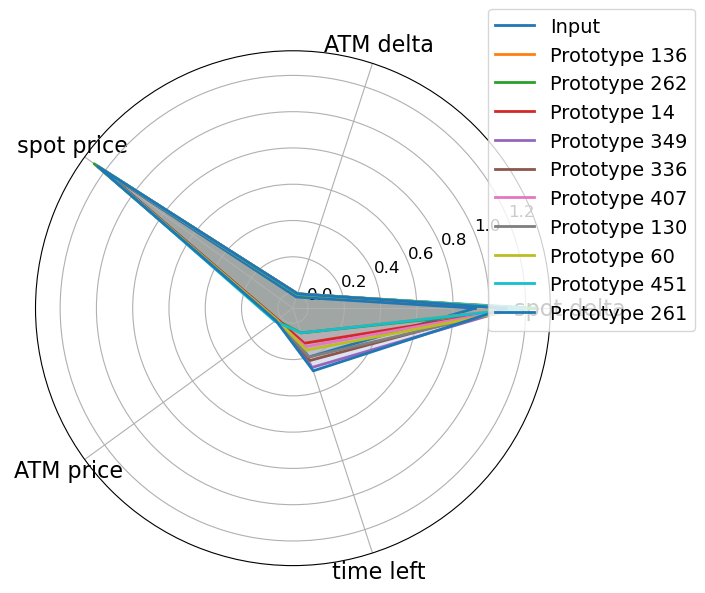

In [86]:
import matplotlib.pyplot as plt
import numpy as np

# -- Use the right input --
t = 10 # pick a timestep you want
x_input_scaled = X_scaled[t]                         # shape: (5,)
x_input_raw = scaler.inverse_transform([x_input_scaled])[0]  # shape: (5,)

# -- Get the top 3 prototypes --
top3_idx = np.argsort(-similarities[t].numpy())[:10]
prototypes_scaled = prototypes[top3_idx]                    # (3, 5)
prototypes_raw = scaler.inverse_transform(prototypes_scaled)

# -- Prepare radar plot --
vectors = [x_input_raw] + list(prototypes_raw)
labels = ["Input"] + [f"Prototype {idx}" for idx in top3_idx]

feature_names = ["spot delta", "ATM delta", " spot price", "ATM price", "time left"]
angles = np.linspace(0, 2 * np.pi, len(feature_names), endpoint=False).tolist()
angles += angles[:1]  # close the circle

vectors_closed = [np.append(v, v[0]) for v in vectors]

# -- Plot --
plt.figure(figsize=(7, 6))
ax = plt.subplot(111, polar=True)

for vec, label in zip(vectors_closed, labels):
    ax.plot(angles, vec, label=label, linewidth=2)
    ax.fill(angles, vec, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feature_names, fontsize=16)
# ax.set_title(f"Step {t}")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

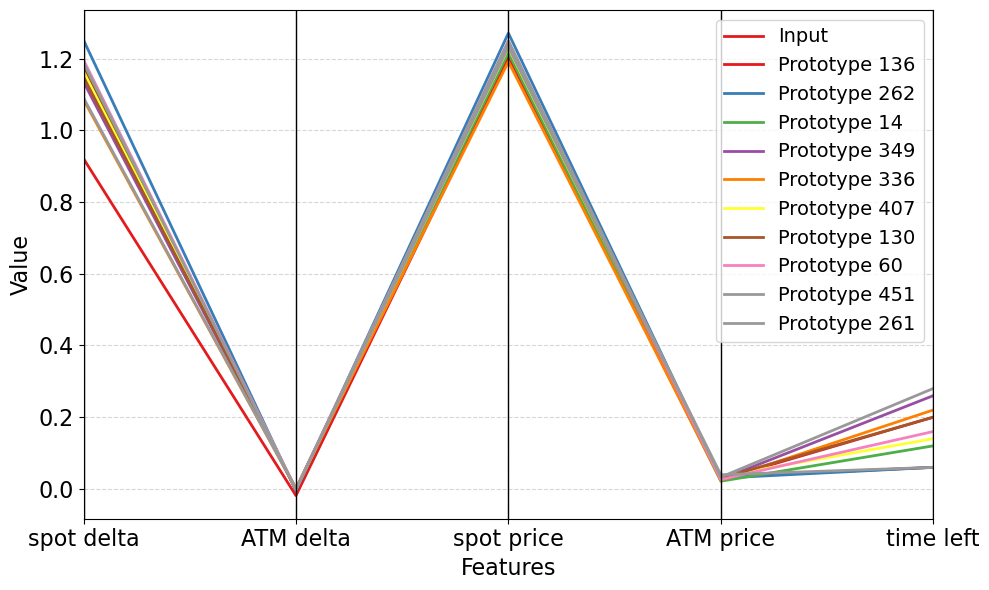

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -- Parameters --
t = 10  # timestep to explain
top_n = 10
feature_names = ["spot delta", "ATM delta", "spot price", "ATM price", "time left"]

# -- Extract input & prototypes --
x_input_scaled = X_scaled[t]
x_input_raw = scaler.inverse_transform([x_input_scaled])[0]

# -- Top-N prototypes at step t --
topN_idx = np.argsort(-similarities[t].numpy())[:top_n]
protos_scaled = prototypes[topN_idx]
protos_raw = scaler.inverse_transform(protos_scaled)

# -- Prepare dataframe --
rows = [x_input_raw] + list(protos_raw)
labels = ["Input"] + [f"Prototype {i}" for i in topN_idx]
df = pd.DataFrame(rows, columns=feature_names)
df["Type"] = labels

# -- Plot parallel coordinates --
plt.figure(figsize=(10, 6))
pd.plotting.parallel_coordinates(df, class_column="Type", colormap=plt.cm.Set1, linewidth=2)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("Features", fontsize=16)
plt.ylabel("Value", fontsize=16)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [15]:
print("Mean Utility (unhedged):", test_result["utility0"].numpy().mean())
print("Mean Utility (hedged):", test_result["utility"].numpy().mean())
print("pnl", test_result["pnl"].numpy().mean())

Mean Utility (unhedged): -0.12461545
Mean Utility (hedged): -0.09042292
pnl 0.004127824


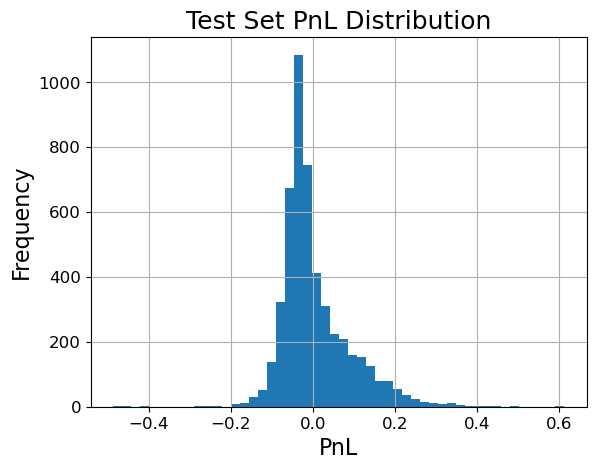

In [16]:
# PNL Analysis

plt.hist(test_result["pnl"].numpy(), bins=50)
plt.title("Test Set PnL Distribution")
plt.xlabel("PnL")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

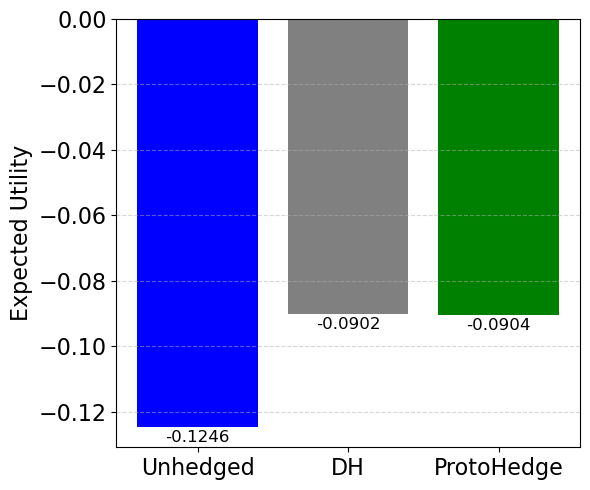

In [ ]:
import matplotlib.pyplot as plt

test_result_vanilla = vanilla_stoch_gym(test_world.tf_data)

# Values from your results
unhedged_utility = test_result["utility0"].numpy().mean()
vanilla_dh_utility = test_result_vanilla["utility"].numpy().mean()
proto_dh_utility = test_result["utility"].numpy().mean()

# Labels and values
labels = ['Unhedged', 'DH', 'ProtoHedge']
values = [unhedged_utility, vanilla_dh_utility, proto_dh_utility]
colors = ['blue', 'gray', 'green']

# Plot
plt.figure(figsize=(6, 5))
bars = plt.bar(labels, values, color=colors)

plt.ylabel("Expected Utility", fontsize=16) 
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# plt.title("Expected Utility Comparison in Stochastic (CVaR@50%)")
plt.grid(True, linestyle="--", alpha=0.5, axis='y')

# Annotate values on top
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, val - 0.0055, f"{val:.4f}",
             ha='center', va='bottom', fontsize=14)

plt.tight_layout()
plt.show()

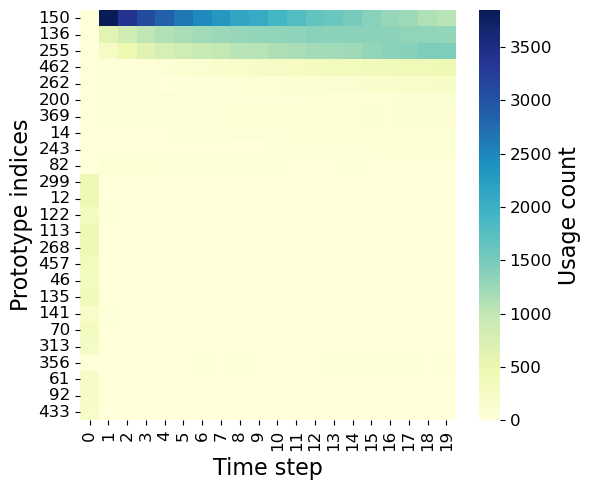

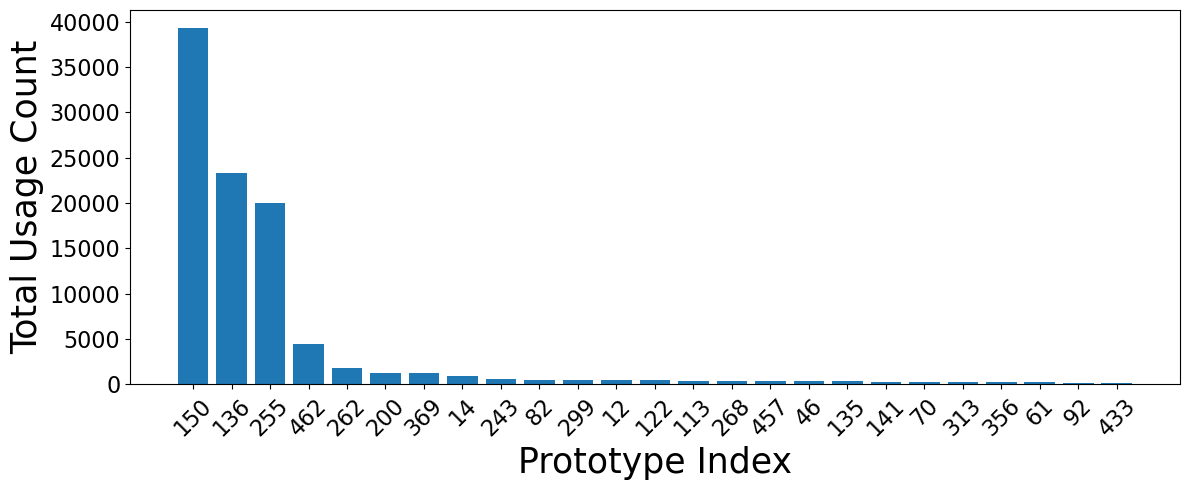

In [18]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Extract features
price = test_world.data.features.per_step['price']         # shape: [B, T, 2]
time_left = test_world.data.features.per_step['time_left'] # shape: [B, T]
actions = test_result['actions'].numpy()                   # shape: [B, T, 2]

# Compute deltas
B, T, _ = price.shape
delta = np.cumsum(actions, axis=1) - actions               # shape: [B, T, 2]

# Extract components
delta_1 = delta[:, :, 0]
delta_2 = delta[:, :, 1]
price_1 = price[:, :, 0]
price_2 = price[:, :, 1]

# Build feature matrix and reshape to [B*T, D]
X = np.stack([delta_1, delta_2, price_1, price_2, time_left], axis=2).reshape(-1, 5)  # [B*T, 5]

# Scale features using saved scaler
X_scaled = scaler.transform(X)

# Retrieve prototype layer
proto_layer = gym.agent.proto_layer
prototypes = proto_layer.prototypes.numpy()                 # [P, D]
n_prototypes = prototypes.shape[0]
D = prototypes.shape[1]

feature_weights = tf.convert_to_tensor(proto_layer.feature_weights.numpy(), dtype=tf.float32)  # shape (D,)


# Compute similarities with feature weighting
x_tf = tf.convert_to_tensor(X_scaled, dtype=tf.float32)     # [B*T, D]
x_exp = tf.expand_dims(x_tf, axis=1)                        # [B*T, 1, D]
p_exp = tf.expand_dims(proto_layer.prototypes, axis=0)      # [1, P, D]

diff = x_exp - p_exp                                        # [B*T, P, D]
weighted_diff = diff * feature_weights                      # [B*T, P, D]
distances = tf.reduce_sum(tf.square(weighted_diff), axis=2) # [B*T, P]
similarities = tf.nn.softmax(-distances, axis=1)            # [B*T, P]
closest = tf.argmax(similarities, axis=1).numpy()           # [B*T]

# Rebuild [B, T] assignment matrix
closest_matrix = closest.reshape(B, T)

# Count usage: heatmap[proto_idx, t] = usage count at time step t
heatmap = np.zeros((n_prototypes, T))
for t in range(T):
    unique, counts = np.unique(closest_matrix[:, t], return_counts=True)
    heatmap[unique, t] = counts

# --- Heatmap of Top 25 Prototypes ---
totals = np.sum(heatmap, axis=1)
top_indices = np.argsort(totals)[-25:][::-1]   # Top 25 most used
filtered_heatmap = heatmap[top_indices]

plt.figure(figsize=(6, 5))
sns.heatmap(filtered_heatmap, cmap="YlGnBu", cbar_kws={'label': 'Usage count'}, yticklabels=top_indices)
plt.xlabel("Time step")
plt.ylabel("Prototype indices")
plt.tight_layout()
plt.show()

# --- Bar Plot of Total Usage Counts ---
top_25_vals = totals[top_indices]

plt.figure(figsize=(12, 5))
plt.bar(range(25), top_25_vals, tick_label=top_indices)
plt.xlabel("Prototype Index", fontsize=25)
plt.ylabel("Total Usage Count", fontsize=25)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

In [133]:
import numpy as np
import pandas as pd
from IPython.display import display

# STEP 1: Get prototypes and actions directly from the model layer
proto_layer = gym.agent.proto_layer
prototypes_np = proto_layer.prototypes.numpy()
proto_actions_np = proto_layer.prototype_actions.numpy()

# STEP 2: Select top 10 prototype indices
top_10_idx = np.array(top_indices[:10], dtype=int)

# STEP 3: Extract prototype features and actions
top_10_prototypes = prototypes_np[top_10_idx]
top_10_actions = proto_actions_np[top_10_idx]

# STEP 4: Inverse scale features back to financial space
original_features = scaler.inverse_transform(top_10_prototypes)

# STEP 5: Build DataFrame
df = pd.DataFrame(original_features, columns=["delta_1", "delta_2", "price_1", "price_2", "time_left"])
df["action_1"] = top_10_actions[:, 0]
df["action_2"] = top_10_actions[:, 1]
df["prototype_index"] = top_10_idx

# Reorder columns for readability
df = df[["prototype_index", "delta_1", "delta_2", "price_1", "price_2", "time_left", "action_1", "action_2"]]

# STEP 6: Display
display(df)

,prototype_index,delta_1,delta_2,price_1,price_2,time_left,action_1,action_2
0,249,-0.078215,0.173851,0.676409,0.020288,0.24,-0.790240,-0.185144
1,562,-0.061386,0.173844,0.796969,0.018126,0.16,-0.417017,-0.091474
2,737,0.011941,0.194207,0.943506,0.029093,0.04,-0.347937,-0.173913
3,741,-0.030131,0.158268,0.912444,0.016315,0.04,0.380809,-0.313166
4,842,-0.067119,0.236488,0.804559,0.028350,0.12,-0.422909,-0.149207
5,772,0.401615,0.007017,0.993589,0.023458,0.34,0.058848,-0.009181
6,613,0.537790,0.006063,0.976680,0.024926,0.36,-0.218720,-0.062807
7,115,0.837243,0.032091,1.091901,0.019540,0.08,0.147690,-0.045138
8,800,-0.013171,0.106706,0.931562,0.020049,0.04,-0.111816,-0.298884
9,66,-0.076803,0.336988,0.722265,0.025129,0.16,-0.684095,-0.248722


In [142]:
# Assuming 'totals' is the array of usage counts per prototype (from earlier heatmap step)

num_used_prototypes = np.sum(totals > 0)
print(f"Number of used prototypes: {num_used_prototypes}")

Number of used prototypes: 899


In [130]:
agent = gym.agent
agent.print_sample_prototypes([737]) 

Prototype 737: Features = [-1.3433964  2.4020078 -0.5203521  1.1476985 -1.474087 ], Action = [-0.54375887 -0.22329617]


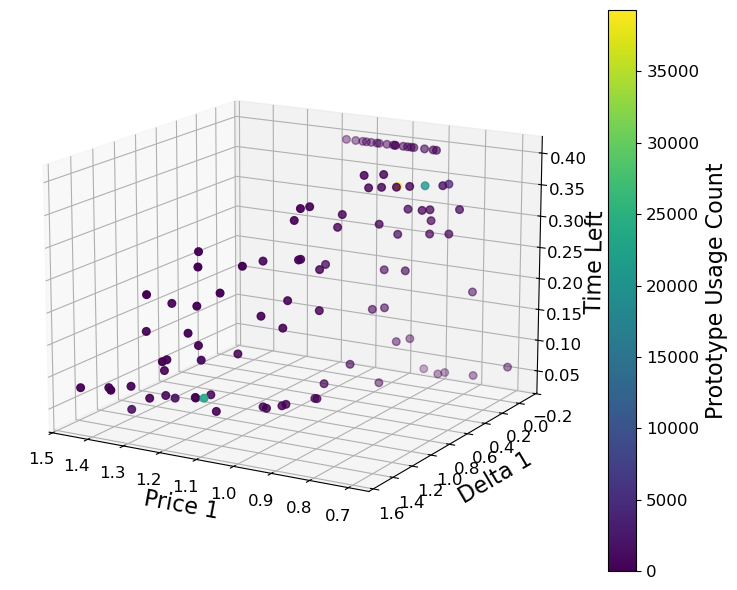

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Extract prototype features
features = proto_layer.prototypes.numpy()  # shape: (num_prototypes, 5)
features_raw = scaler.inverse_transform(features)
price_1 = features_raw[:, 2]
delta_1 = features_raw[:, 0]
time_left = features_raw[:, 4]

# Compute total usage
usage_counts = np.sum(heatmap, axis=1)

# Get indices of top 25 prototypes
top_25_indices = np.argsort(usage_counts)[-100:]
price_1_top = price_1[top_25_indices]
delta_1_top = delta_1[top_25_indices]
time_left_top = time_left[top_25_indices]
usage_top = usage_counts[top_25_indices]

# Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(price_1_top, delta_1_top, time_left_top, c=usage_top, cmap='viridis', s=30)

ax.view_init(elev=15, azim=120)
ax.set_xlabel("Price 1")
ax.set_ylabel("Delta 1")
ax.set_zlabel("Time Left")
fig.colorbar(p, ax=ax, label="Prototype Usage Count")

plt.tight_layout()
plt.show()

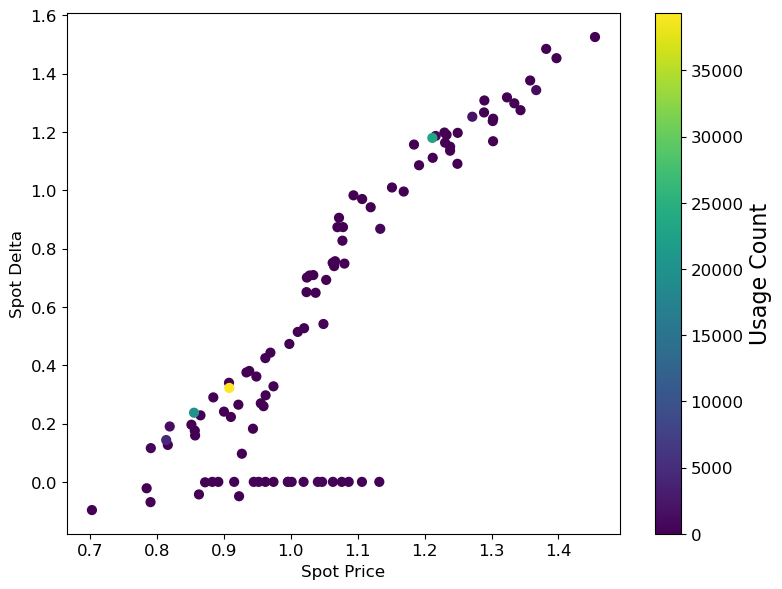

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Extract prototype features and reverse scaling
features = proto_layer.prototypes.numpy()  # shape: (num_prototypes, 5)
features_raw = scaler.inverse_transform(features)
price_1 = features_raw[:, 2]
delta_1 = features_raw[:, 0]

# Compute total usage
usage_counts = np.sum(heatmap, axis=1)

# Get indices of top 25 most-used prototypes
top_25_indices = np.argsort(usage_counts)[-100:]
price_1_top = price_1[top_25_indices]
delta_1_top = delta_1[top_25_indices]
usage_top = usage_counts[top_25_indices]

# 2D Scatter Plot
plt.figure(figsize=(8, 6))
sc = plt.scatter(price_1_top, delta_1_top, c=usage_top, cmap='viridis', s=40)

plt.xlabel("Spot Price", fontsize=12)
plt.ylabel("Spot Delta", fontsize=12)
plt.colorbar(sc, label="Usage Count")
plt.tight_layout()
plt.show()

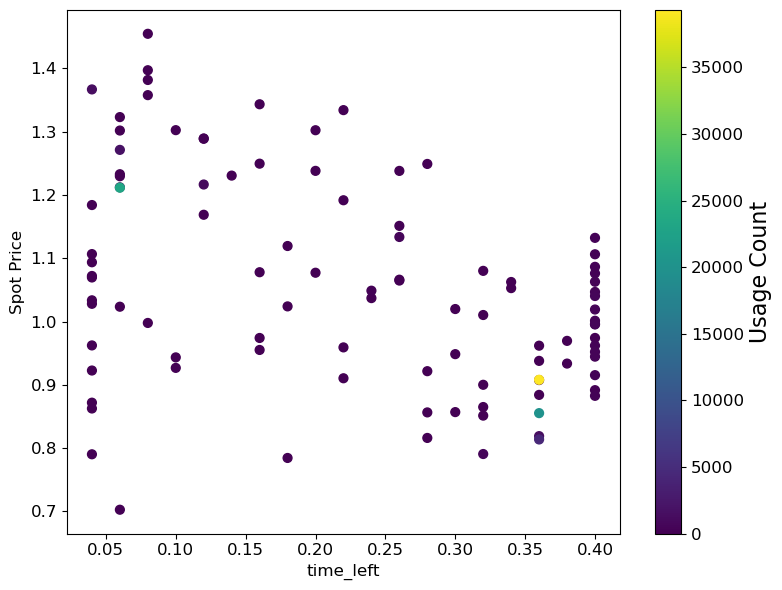

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Extract prototype features and reverse scaling
features = proto_layer.prototypes.numpy()  # shape: (num_prototypes, 5)
features_raw = scaler.inverse_transform(features)
time = features_raw[:, 4]
price_1 = features_raw[:, 2]

# Compute total usage
usage_counts = np.sum(heatmap, axis=1)

# Get indices of top 25 most-used prototypes
top_25_indices = np.argsort(usage_counts)[-100:]
price_1_top = price_1[top_25_indices]
time_top = time[top_25_indices]
usage_top = usage_counts[top_25_indices]

# 2D Scatter Plot
plt.figure(figsize=(8, 6))
sc = plt.scatter(time_top, price_1_top, c=usage_top, cmap='viridis', s=40)

plt.xlabel("time_left", fontsize=12)
plt.ylabel("Spot Price", fontsize=12)
plt.colorbar(sc, label="Usage Count")
plt.tight_layout()
plt.show()

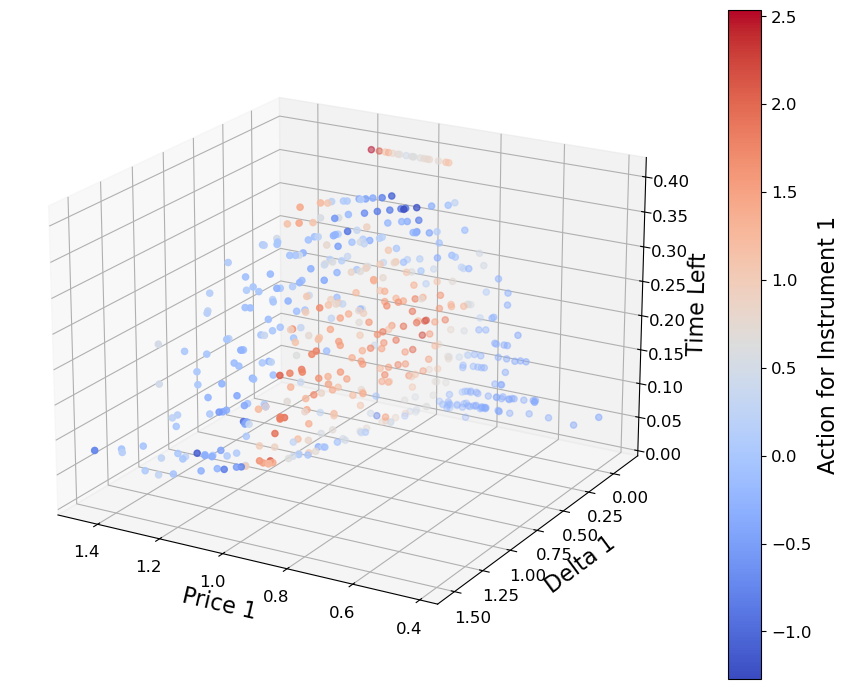

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load prototype data
with open(f"./prototypes_storage/prototypes_stochastic_{n_prototypes}.pkl", "rb") as f:
    data = pickle.load(f)

prototypes = data["prototypes"]        # shape (1000, 5)
proto_actions = gym.agent.proto_layer.prototype_actions.numpy()  # shape (1000, 2)

# 1. Reverse scale: get interpretable values
prototypes_raw = scaler.inverse_transform(prototypes)  # shape: [N, 5]

# 2. Select interpretable features
price_1 = prototypes_raw[:, 2]
delta_1 = prototypes_raw[:, 0]
time_left = prototypes_raw[:, 4]
action_1 = proto_actions[:, 0]  # Action for instrument 1

# 3. Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(price_1, delta_1, time_left, c=action_1, cmap='coolwarm', s=20)

ax.set_xlabel("Price 1")
ax.set_ylabel("Delta 1")
ax.set_zlabel("Time Left")
fig.colorbar(p, ax=ax, label="Action for Instrument 1")

ax.view_init(elev=20, azim=120)  # <- adjust these values as needed

plt.tight_layout()
plt.show()

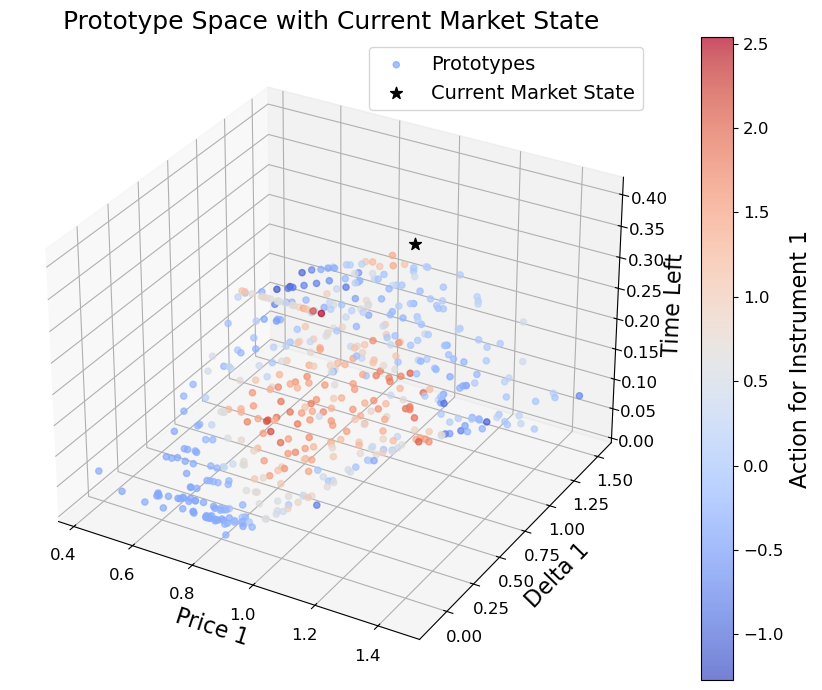

In [23]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pickle

# Load prototype data
with open(f"./prototypes_storage/prototypes_stochastic_{n_prototypes}.pkl", "rb") as f:
    data = pickle.load(f)

prototypes = data["prototypes"]        # shape (1000, 5)
proto_actions = gym.agent.proto_layer.prototype_actions.numpy()  # shape (1000, 2)

# 1. Reverse scale: get interpretable prototype features
prototypes_raw = scaler.inverse_transform(prototypes)  # shape: [N, 5]

# 2. Extract prototype features
price_1 = prototypes_raw[:, 2]
delta_1 = prototypes_raw[:, 0]
time_left = prototypes_raw[:, 4]
action_1 = proto_actions[:, 0]  # Action for instrument 1

# 3. Get current market state from step t (e.g. step 19 of last trajectory)
t = 1
price = test_world.data.features.per_step['price'][-1][t]       # shape (2,)
delta = np.cumsum(test_result['actions'][-1], axis=0) - test_result['actions'][-1]
delta = delta[t]
time = test_world.data.features.per_step['time_left'][-1][t]

# 4. Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot prototypes
p = ax.scatter(price_1, delta_1, time_left, c=action_1, cmap='coolwarm', s=20, alpha=0.7, label='Prototypes')

# Plot current market state as a large black star
ax.scatter(price[0], delta[0], time, c='black', s=80, marker='*', label='Current Market State')

# Axes labels
ax.set_xlabel("Price 1")
ax.set_ylabel("Delta 1")
ax.set_zlabel("Time Left")
ax.set_title("Prototype Space with Current Market State")

# Colorbar
fig.colorbar(p, ax=ax, label="Action for Instrument 1")

# Legend
ax.legend()

plt.tight_layout()
plt.show()

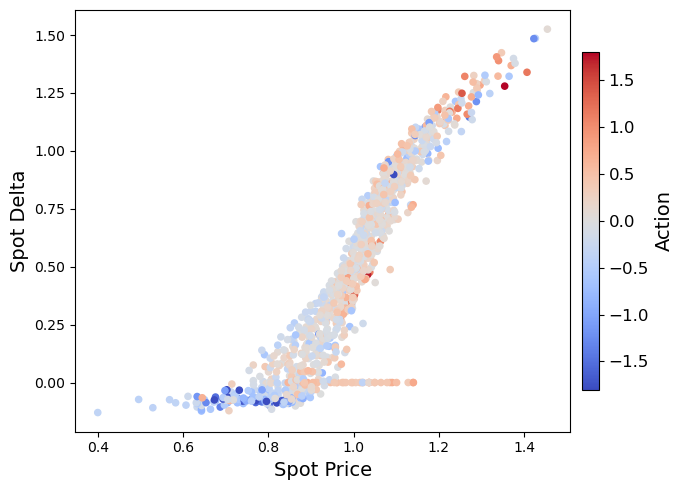

In [137]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Set symmetric color limits around 0
abs_max = np.max(np.abs(action_1))
symmetric_limit = np.ceil(abs_max * 5) / 10
norm = TwoSlopeNorm(vmin=-symmetric_limit, vcenter=0.0, vmax=symmetric_limit)

# 2D scatter plot
plt.figure(figsize=(7, 5))
sc = plt.scatter(price_1, delta_1, c=action_1, cmap='coolwarm', norm=norm, s=20)

# Axis labels and styling
plt.xlabel("Spot Price", fontsize=14)
plt.ylabel("Spot Delta", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Colorbar
cbar = plt.colorbar(sc, shrink=0.8, pad=0.02)
cbar.set_label("Action", fontsize=14)

plt.tight_layout()
plt.show()

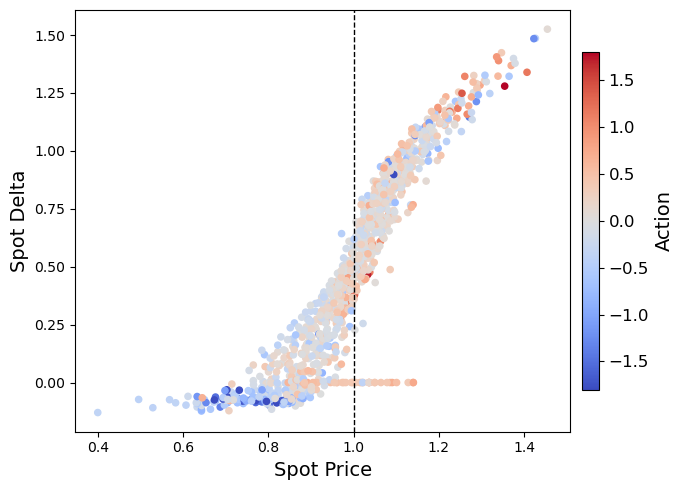

In [177]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Set symmetric color limits around 0
abs_max = np.max(np.abs(action_1))
symmetric_limit = np.ceil(abs_max * 5) / 10
norm = TwoSlopeNorm(vmin=-symmetric_limit, vcenter=0.0, vmax=symmetric_limit)

# 2D scatter plot
plt.figure(figsize=(7, 5))
sc = plt.scatter(price_1, delta_1, c=action_1, cmap='coolwarm', norm=norm, s=20)

# Add vertical dashed line at price = 1.0
plt.axvline(x=1.0, color='black', linestyle='--', linewidth=1)

# Axis labels and styling
plt.xlabel("Spot Price", fontsize=14)
plt.ylabel("Spot Delta", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Colorbar
cbar = plt.colorbar(sc, shrink=0.8, pad=0.02)
cbar.set_label("Action", fontsize=14)

plt.tight_layout()
plt.show()

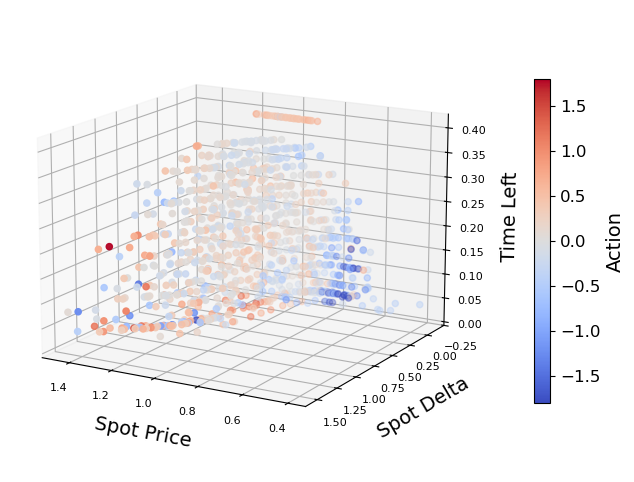

In [176]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Set symmetric color scale
abs_max = np.max(np.abs(action_1))
symmetric_limit = np.ceil(abs_max * 5) / 10
norm = TwoSlopeNorm(vmin=-symmetric_limit, vcenter=0.0, vmax=symmetric_limit)

# Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(price_1, delta_1, time_left, c=action_1, cmap='coolwarm', norm=norm, s=20)

# Adjust font sizes and spacing
ax.view_init(elev=15, azim=120)
ax.set_xlabel("Spot Price", fontsize=14, labelpad=8)
ax.set_ylabel("Spot Delta", fontsize=14, labelpad=8)
ax.set_zlabel("Time Left", fontsize=14, labelpad=8)


ax.tick_params(axis='both', which='major', labelsize=8)

# Add colorbar
cbar = fig.colorbar(p, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label("Action", fontsize=14)

plt.show()